In [1]:
!pip install statsmodels
!pip install numpy --upgrade --break-system-packages
!pip install pandas --upgrade --break-system-packages
!pip install statsmodels --upgrade --break-system-packages


In [2]:
import subprocess
subprocess.run(['pip', 'install', 'statsmodels', '--upgrade', '--break-system-packages'])

CompletedProcess(args=['pip', 'install', 'statsmodels', '--upgrade', '--break-system-packages'], returncode=0)

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.signal import find_peaks
from itertools import product as iterproduct

In [4]:
sales_data = pd.read_csv("sales_data.csv")

<h1> Converting Date</h1>

In [6]:
sales_data["Date"] = pd.to_datetime(sales_data["Date"])
sales_data = sales_data.sort_values("Date")
sales_data.info()

<class 'pandas.DataFrame'>
Index: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[us]
 1   Store ID            76000 non-null  str           
 2   Product ID          76000 non-null  str           
 3   Category            76000 non-null  str           
 4   Region              76000 non-null  str           
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  str           
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  str           
 14  Epidem

In [7]:
sales_data["Date"].min(), sales_data["Date"].max(), sales_data["Date"].nunique()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-30 00:00:00'), 760)

<h2>Observations per date check</h2>

In [9]:
obs_per_date = sales_data.groupby("Date").size()
obs_per_date.describe()

count    760.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
dtype: float64

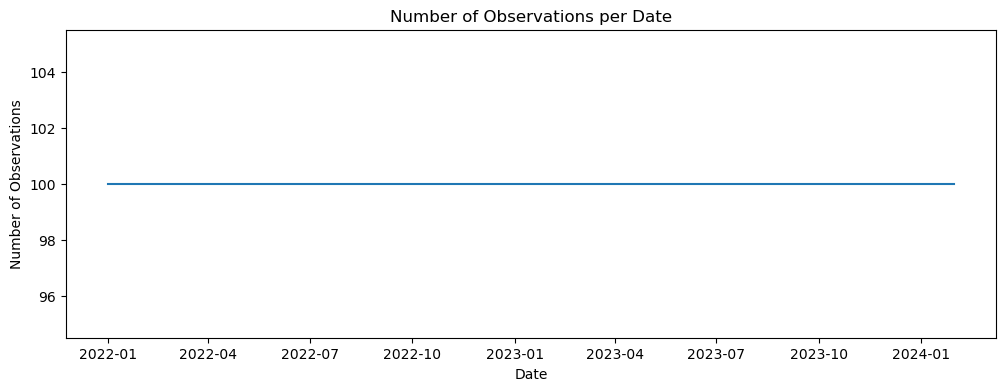

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(obs_per_date.index, obs_per_date.values)
plt.title("Number of Observations per Date")
plt.xlabel("Date")
plt.ylabel("Number of Observations")
plt.show()

<h2> Further data cleaning</h2>

In [12]:
sales_data[["Store ID", "Product ID", "Category", "Region"]].nunique()
sales_data["series_id"] = sales_data["Store ID"].astype(str) + "_" + sales_data["Product ID"].astype(str)
sales_data[["Date", "series_id", "Store ID", "Product ID", "Units Sold"]].head()
sales_data["series_id"].nunique()
series_lengths = sales_data.groupby("series_id")["Date"].nunique()
series_lengths.describe()

count    100.0
mean     760.0
std        0.0
min      760.0
25%      760.0
50%      760.0
75%      760.0
max      760.0
Name: Date, dtype: float64

All 100 unique time series's have equal length, and do not need to fill forward missing values.

<h2>Duplicate and missing date checks</h2>

In [15]:
sales_data.duplicated().sum()
sales_data.duplicated(subset=["Date", "Store ID", "Product ID"]).sum()
date_range = pd.date_range(start=sales_data["Date"].min(), end=sales_data["Date"].max(), freq="D")
missing_dates = date_range.difference(sales_data["Date"].unique())
missing_dates
len(missing_dates)

0

No missing dates

<h2>Duplicate Records Check</h2>

In [18]:
sales_data.duplicated().sum()

np.int64(0)

In [19]:
sales_data.duplicated(subset=["Date", "Store ID", "Product ID"]).sum()

np.int64(0)

In [20]:
missing_summary

NameError: name 'missing_summary' is not defined

No missing or duplicate cells 

<h2>Invalid Numerical Values Check</h2>

In [21]:
numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Promotion",
    "Epidemic",
    "Demand"
]

sales_data[numeric_cols].describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Promotion,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,69.454029,0.328947,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,40.943818,0.469834,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,4.290000,0.000000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,32.620000,0.000000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,65.700000,0.000000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,97.932500,1.000000,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,261.220000,1.000000,1.000000,430.000000


In [23]:
zero_check = (sales_data[numeric_cols] == 0).sum().reset_index()
zero_check.columns = ["column", "zero_count"]
zero_check

,column,zero_count
0,Inventory Level,406
1,Units Sold,406
2,Units Ordered,47107
3,Price,0
4,Discount,17126
5,Competitor Pricing,0
6,Promotion,51000
7,Epidemic,60800
8,Demand,0


No invalid values

<h2>EDA</h2>

In [27]:
numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Promotion",
    "Epidemic",
    "Demand"
]

sales_data[numeric_cols].describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Promotion,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,69.454029,0.328947,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,40.943818,0.469834,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,4.290000,0.000000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,32.620000,0.000000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,65.700000,0.000000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,97.932500,1.000000,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,261.220000,1.000000,1.000000,430.000000


Units sold mean around 88,82, with min of 0 and max of 426. Demand is generally higher than units sold, Inventory level shows substantial variation due to its high sdev. Units ordered have a median of 0, suggesting that at least half of the observations have no new units ordered, maybe showing ordering is not continuous everyday.

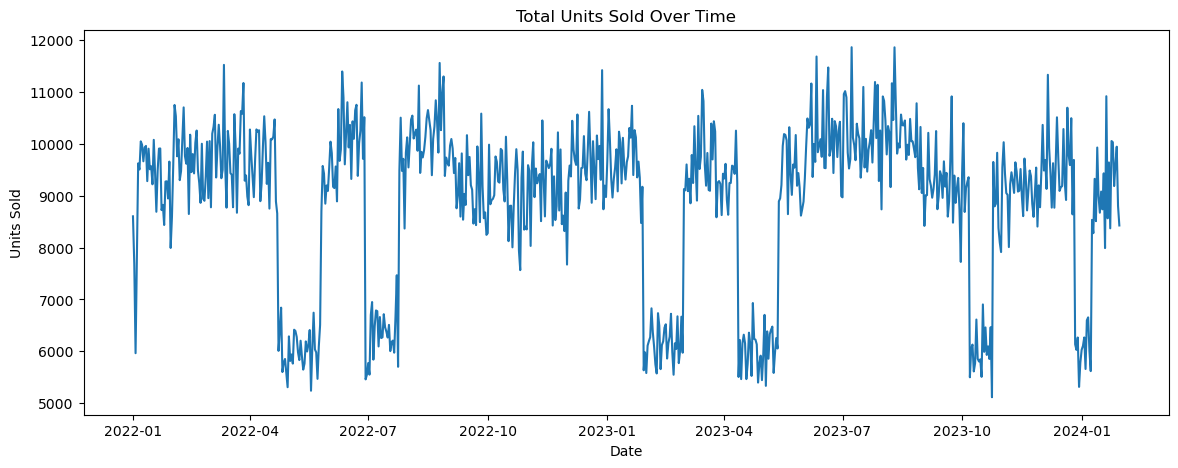

In [30]:
daily_units_sold = sales_data.groupby("Date")["Units Sold"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_units_sold["Date"], daily_units_sold["Units Sold"])
plt.title("Total Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

The total units sold series shows a clear repeating seasonal pattern, with regular sharp drops followed by recovery across the full horizon. Sales usually fluctuate around 8,500–10,500 units, but fall to around 5,500–6,500 units during low-sales periods. This suggests the data is suitable for time series forecasting because it contains visible seasonality, changing short-term fluctuations, and possible structural/holiday-style effects that should be considered before modelling.

In [33]:
target = "Units Sold"

sales_data[target].agg([
    "mean",
    "std",
    "min",
    "max",
    "skew",
    "kurt"
]).round(3)

mean     88.827
std      43.995
min       0.000
max     426.000
skew      0.790
kurt      1.249
Name: Units Sold, dtype: float64

The positive skewness of 0.790 indicates a right-skewed distribution, meaning occasional high-sales observations are present. The positive kurtosis of 1.249 suggests heavier tails and possible extreme sales spikes, so outlier and seasonality checks are important before forecasting.

<h2>Time series decomposition</h2>

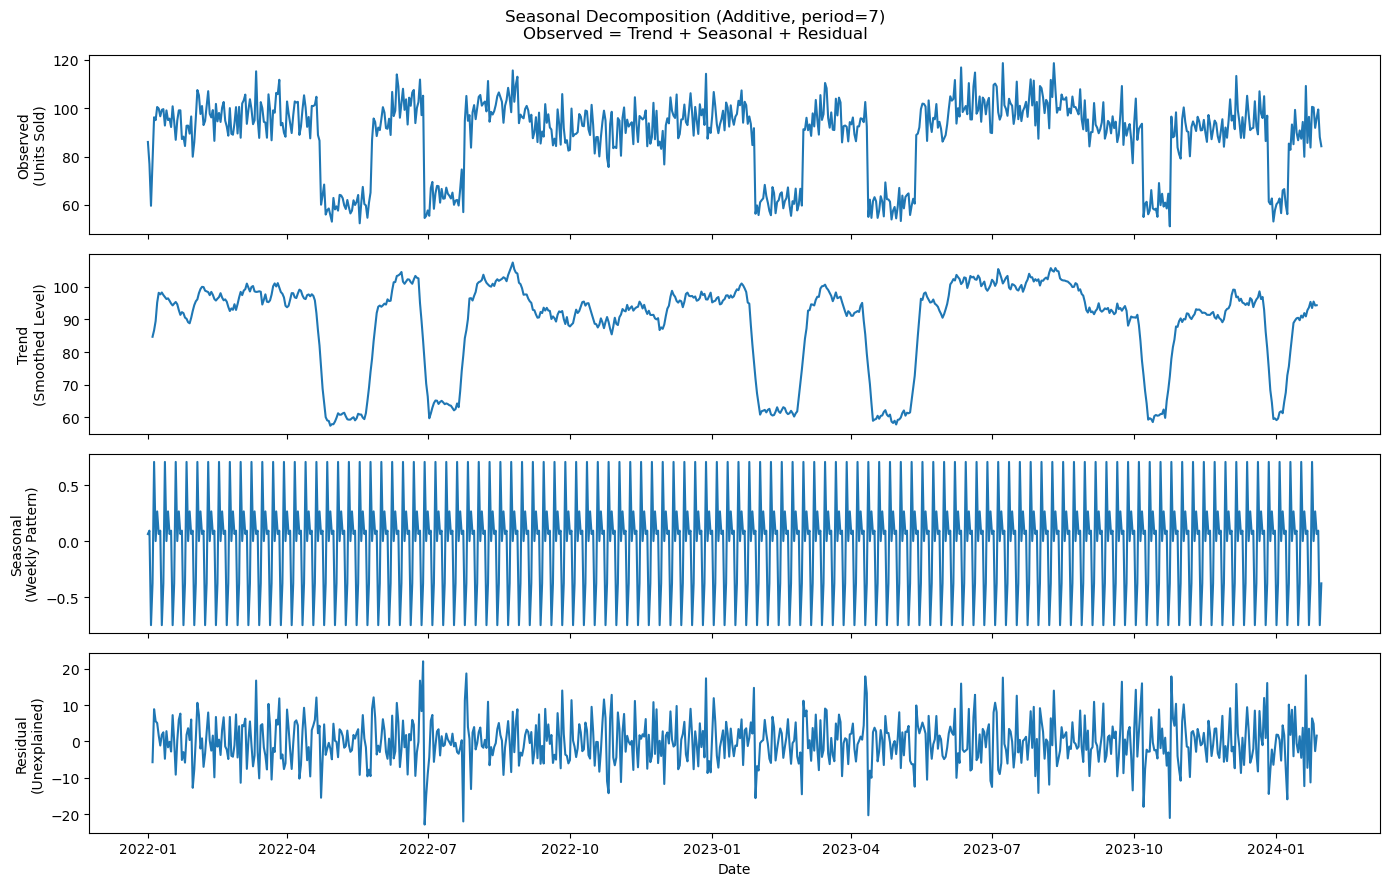

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_avg_units_sold = sales_data.groupby("Date")["Units Sold"].mean()
daily_avg_units_sold = daily_avg_units_sold.asfreq("D")

decomposition = seasonal_decompose(
    daily_avg_units_sold,
    model="additive",
    period=7
)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

fig.suptitle(
    "Seasonal Decomposition (Additive, period=7)\nObserved = Trend + Seasonal + Residual",
    fontsize=12
)

axes[0].plot(decomposition.observed)
axes[0].set_ylabel("Observed\n(Units Sold)")

axes[1].plot(decomposition.trend)
axes[1].set_ylabel("Trend\n(Smoothed Level)")

axes[2].plot(decomposition.seasonal)
axes[2].set_ylabel("Seasonal\n(Weekly Pattern)")

axes[3].plot(decomposition.resid)
axes[3].set_ylabel("Residual\n(Unexplained)")

axes[3].set_xlabel("Date")

plt.tight_layout()
plt.show()

<h2>ACF and PACF</h2>

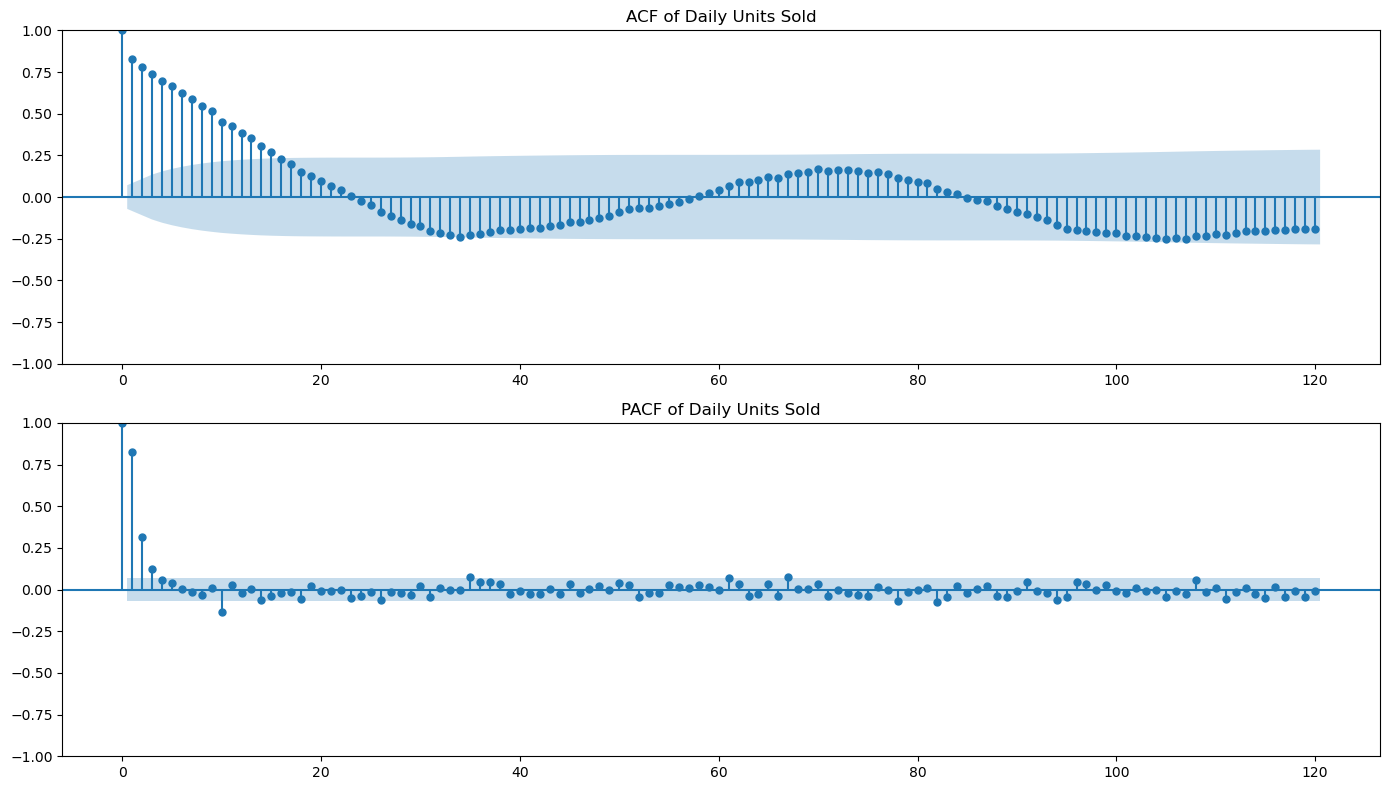

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Convert date column
sales_data['Date'] = pd.to_datetime(sales_data['Date'])

# Aggregate daily units sold
daily_units_sold = (
    sales_data.groupby('Date')['Units Sold']
    .sum()
)

# Plot ACF and PACF
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(daily_units_sold, lags=120, ax=axes[0])
axes[0].set_title("ACF of Daily Units Sold")

plot_pacf(
    daily_units_sold,
    lags=120,
    ax=axes[1],
    method='ywm'
)
axes[1].set_title("PACF of Daily Units Sold")

plt.tight_layout()
plt.show()

The ACF shows a slow, wave-like decay, which means Units Sold has strong time dependence and is not behaving like random noise. The repeated rise and fall pattern also suggests a seasonal or cyclical structure in the sales series. Because the ACF does not cut off quickly, the original series is likely not fully stationary and may require differencing or seasonal modelling.

The PACF shows a large significant spike at lag 1 and a smaller spike around lag 2, then most later lags become much weaker. This suggests that recent sales values, especially the previous day, are important for explaining current sales. In QBUS3850 terms, this supports considering AR-style components, especially low-order AR terms.

Overall, the ACF/PACF results suggest that Units Sold has strong autocorrelation, possible seasonality, and non-stationary behaviour, so forecasting models should not treat observations as independent. Models such as ARIMA/SARIMA, exponential smoothing, or models with seasonal components would be more suitable than a simple static average model.

<h3>Further 'outlier' detection</h3>

In [45]:
q1 = daily_units_sold.quantile(0.25)
q3 = daily_units_sold.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = daily_units_sold[(daily_units_sold < lower_bound) | (daily_units_sold > upper_bound)]

outlier_summary = pd.DataFrame({
    "Metric": [
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Number of Outliers",
        "Outlier Percentage",
        "Minimum Outlier",
        "Maximum Outlier"
    ],
    "Value": [
        q1,
        q3,
        iqr,
        lower_bound,
        upper_bound,
        outliers.shape[0],
        outliers.shape[0] / daily_units_sold.shape[0] * 100,
        outliers.min() if outliers.shape[0] > 0 else None,
        outliers.max() if outliers.shape[0] > 0 else None
    ]
})

outlier_summary["Value"] = outlier_summary["Value"].round(3)
outlier_summary

,Metric,Value
0,Q1,8524.000
1,Q3,9926.500
2,IQR,1402.500
3,Lower Bound,6420.250
4,Upper Bound,12030.250
5,Number of Outliers,122.000
6,Outlier Percentage,16.053
7,Minimum Outlier,5117.000
8,Maximum Outlier,6417.000


The outlier check identifies 122 outlier days, which is about 16.05% of the daily sales observations. Using the IQR rule, normal daily sales are expected to fall between 6,420.25 and 12,030.25 units. The detected outliers range from 5,117 to 6,417 units, meaning all outliers are low-sales outliers, not unusually high-sales spikes.

This matches the earlier time series plot, where Units Sold had repeated sharp drops. This also suggests the outliers are likely not random data errors, but recurring low-sales periods caused by seasonality, promotions, inventory shortages, epidemic effects, or other external conditions. Therefore, they should not be automatically removed; they should be treated as meaningful sales shocks or seasonal low-demand periods for forecasting.

## Setup

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# data 
df = pd.read_csv('sales_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

# store x category aggregation 
store_cat = df.groupby(['Date', 'Store ID', 'Category'])['Units Sold'].sum().reset_index()
store_cat = store_cat.sort_values(['Store ID', 'Category', 'Date'])

# exog aggregation 
exog_df = df.groupby(['Date', 'Store ID', 'Category']).agg({
    'Discount': 'mean',
    'Price':    'mean',
    'Epidemic': 'max',
}).reset_index()

#settings 
HOLDOUT = 28
SHORT_HORIZON = 5
LONG_HORIZON  = 28

print(f"Number of series: {store_cat.groupby(['Store ID', 'Category']).ngroups}")
print(f"Date range: {store_cat['Date'].min()} to {store_cat['Date'].max()}")
print(f"Holdout: {HOLDOUT} days")
print(f"Short horizon: {SHORT_HORIZON} days")
print(f"Long horizon: {LONG_HORIZON} days")

Number of series: 24
Date range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00
Holdout: 28 days
Short horizon: 5 days
Long horizon: 28 days


In [55]:
print(df['Store ID'].nunique(), 'stores')
print(df['Product ID'].nunique(), 'products')
print(df['Category'].nunique(), 'categories')
print(df['Region'].nunique(), 'regions')
print(df.groupby(['Store ID', 'Product ID'])['Units Sold'].count().describe())
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total days: {df['Date'].nunique()}")

5 stores
20 products
5 categories
4 regions
count    100.0
mean     760.0
std        0.0
min      760.0
25%      760.0
50%      760.0
75%      760.0
max      760.0
Name: Units Sold, dtype: float64

Date range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00
Total days: 760


In [57]:
print(df['Product ID'].unique())
print(df[['Product ID', 'Category']].drop_duplicates().sort_values('Category'))

<StringArray>
['P0001', 'P0002', 'P0003', 'P0004', 'P0005', 'P0006', 'P0007', 'P0008',
 'P0009', 'P0010', 'P0011', 'P0012', 'P0013', 'P0014', 'P0015', 'P0016',
 'P0017', 'P0018', 'P0019', 'P0020']
Length: 20, dtype: str
   Product ID  Category
1       P0002  Clothing
2       P0003  Clothing
76      P0017  Clothing
70      P0011  Clothing
64      P0005  Clothing
..        ...       ...
16      P0017      Toys
95      P0016      Toys
26      P0007      Toys
44      P0005      Toys
99      P0020      Toys

[64 rows x 2 columns]


In [59]:
print(df[['Discount', 'Price', 'Epidemic']].describe())
print(df['Epidemic'].value_counts())
print(df['Discount'].value_counts())

           Discount         Price      Epidemic
count  76000.000000  76000.000000  76000.000000
mean       9.087039     67.726028      0.200000
std        7.475781     39.377899      0.400003
min        0.000000      4.740000      0.000000
25%        5.000000     31.997500      0.000000
50%       10.000000     64.500000      0.000000
75%       10.000000     95.830000      0.000000
max       25.000000    228.030000      1.000000
Epidemic
0    60800
1    15200
Name: count, dtype: int64
Discount
10    23298
0     17126
5     16918
15     6245
25     6222
20     6191
Name: count, dtype: int64


In [61]:
## assume that price is known befre, discount and epidemic are known before 

In [63]:
print(df.groupby('Category')['Units Sold'].sum().sort_values(ascending=False))
print(df.groupby('Region')['Units Sold'].sum().sort_values(ascending=False))
print(df.groupby('Store ID')['Units Sold'].sum().sort_values(ascending=False))

Category
Groceries      3127335
Clothing       1150873
Furniture       880654
Toys            834679
Electronics     757335
Name: Units Sold, dtype: int64
Region
North    2680946
South    1386126
East     1375613
West     1308191
Name: Units Sold, dtype: int64
Store ID
S002    1386126
S003    1375613
S005    1362812
S001    1318134
S004    1308191
Name: Units Sold, dtype: int64


In [65]:
store_cat = df.groupby(['Date', 'Store ID', 'Category'])['Units Sold'].sum().unstack(['Store ID', 'Category'])
print(store_cat.describe().round(0))

Store ID     S001                                            S002              \
Category Clothing Electronics Furniture Groceries   Toys Clothing Electronics   
count       760.0       760.0     760.0     760.0  760.0    760.0       760.0   
mean        313.0       234.0     260.0     624.0  303.0    452.0       249.0   
std          76.0        73.0      87.0     161.0  117.0     92.0        81.0   
min          64.0        75.0      70.0     214.0   33.0    219.0         0.0   
25%         259.0       182.0     208.0     509.0  246.0    386.0       192.0   
50%         305.0       236.0     264.0     620.0  319.0    443.0       250.0   
75%         362.0       282.0     319.0     729.0  380.0    509.0       305.0   
max         631.0       499.0     552.0    1189.0  659.0    763.0       512.0   

Store ID                             ...   S003     S004              \
Category Furniture Groceries   Toys  ...   Toys Clothing Electronics   
count        760.0     760.0  760.0  ...  760

In [67]:
print(df[['Store ID', 'Region']].drop_duplicates().sort_values('Store ID'))


   Store ID Region
0      S001  North
20     S002  South
40     S003   East
60     S004   West
80     S005  North


<h2 style="color: hotpink;">Max Performance Model — ARIMA Pipeline (Store × Category)</h2>

- arch
- garch
- var
- volocity

In [71]:
store_cat = df.groupby(['Date', 'Store ID', 'Category'])['Units Sold'].sum().reset_index()
store_cat['Date'] = pd.to_datetime(store_cat['Date'])
store_cat = store_cat.sort_values(['Store ID', 'Category', 'Date'])

print(store_cat.head(20))
print(f"\nNumber of series: {store_cat.groupby(['Store ID', 'Category']).ngroups}")
print(store_cat.groupby(['Store ID', 'Category'])['Units Sold'].count().describe())

          Date Store ID  Category  Units Sold
0   2022-01-01     S001  Clothing         319
24  2022-01-02     S001  Clothing         379
48  2022-01-03     S001  Clothing         183
72  2022-01-04     S001  Clothing         201
96  2022-01-05     S001  Clothing         363
120 2022-01-06     S001  Clothing         335
144 2022-01-07     S001  Clothing         241
168 2022-01-08     S001  Clothing         269
192 2022-01-09     S001  Clothing         416
216 2022-01-10     S001  Clothing         481
240 2022-01-11     S001  Clothing         314
264 2022-01-12     S001  Clothing         430
288 2022-01-13     S001  Clothing         480
312 2022-01-14     S001  Clothing         332
336 2022-01-15     S001  Clothing         515
360 2022-01-16     S001  Clothing         336
384 2022-01-17     S001  Clothing         462
408 2022-01-18     S001  Clothing         579
432 2022-01-19     S001  Clothing         329
456 2022-01-20     S001  Clothing         224

Number of series: 24
count     24

In [73]:
from itertools import product

all_combos = pd.DataFrame(list(product(df['Store ID'].unique(), df['Category'].unique())), 
                          columns=['Store ID', 'Category'])
existing = store_cat[['Store ID', 'Category']].drop_duplicates()
missing = all_combos.merge(existing, on=['Store ID', 'Category'], how='left', indicator=True)
print(missing[missing['_merge'] == 'left_only'])


   Store ID Category     _merge
18     S004     Toys  left_only


In [75]:
## store 4 sells no toys

<h3 style="color: orange;">ACF and PACF </h3>

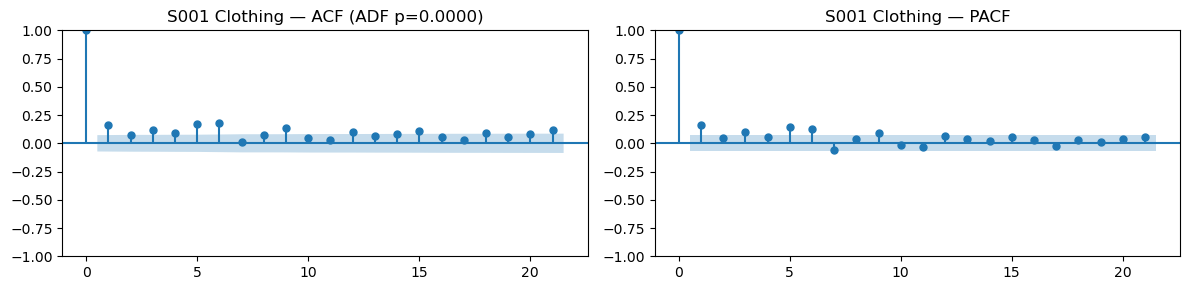

S001 Clothing: ADF p=0.0000 — stationary


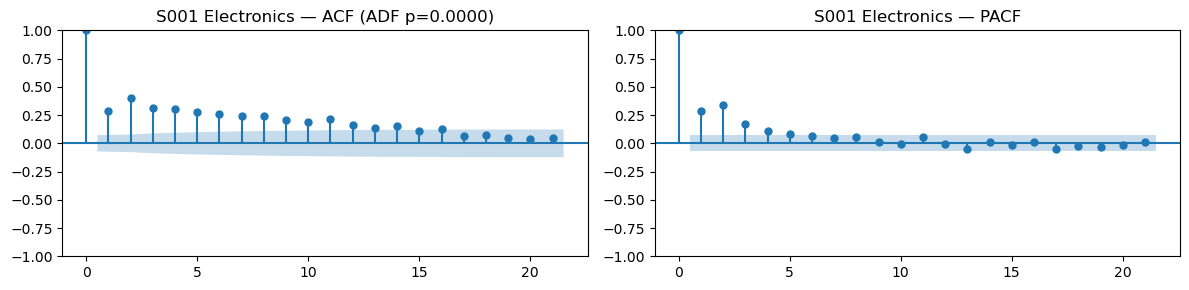

S001 Electronics: ADF p=0.0000 — stationary


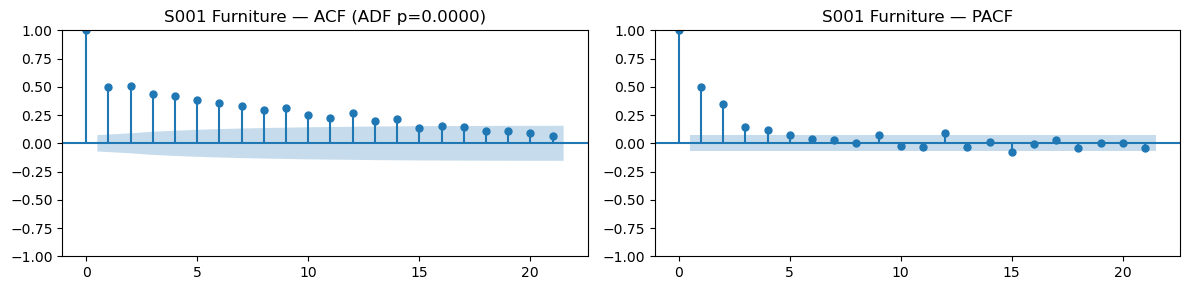

S001 Furniture: ADF p=0.0000 — stationary


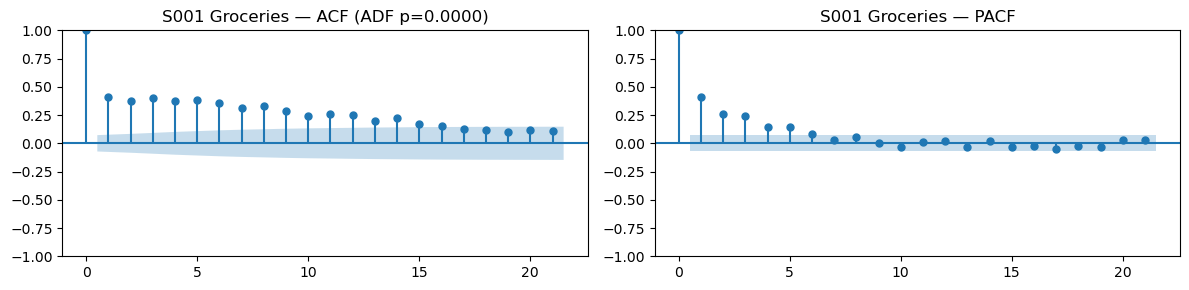

S001 Groceries: ADF p=0.0000 — stationary


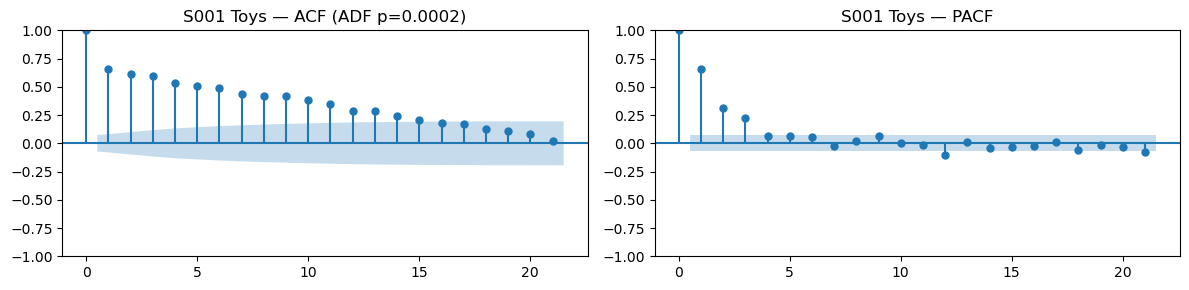

S001 Toys: ADF p=0.0002 — stationary


In [85]:
#inform the candiate order throygh samokes 
representatives = [
    ('S001', 'Clothing'),
    ('S001', 'Electronics'),
    ('S001', 'Furniture'),
    ('S001', 'Groceries'),
    ('S001', 'Toys'),
]

for store, category in representatives:
    ts = store_cat[(store_cat['Store ID'] == store) & 
                   (store_cat['Category'] == category)].set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]

    # stationarity
    adf_p = adfuller(train, autolag='AIC')[1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    plot_acf(train,  lags=21, ax=axes[0])
    plot_pacf(train, lags=21, ax=axes[1])
    axes[0].set_title(f'{store} {category} — ACF (ADF p={adf_p:.4f})')
    axes[1].set_title(f'{store} {category} — PACF')
    plt.tight_layout()
    plt.show()

    print(f"{store} {category}: ADF p={adf_p:.4f} — {'stationary' if adf_p < 0.05 else 'non-stationary'}")

In [86]:
## ACF mostly dies down, PACF cuts iff aroung lag 2 - ar(1)(2)(3)

The ACF and PACF plots were used to assess whether each store-category sales series contained autocorrelation and to guide the choice of ARIMA and SARIMA model orders. The ACF shows how current sales are correlated with past sales values, while the PACF shows the remaining relationship with each lag after controlling for shorter lags.

Overall, the plots suggest that many series contain short-term dependence, meaning recent sales values are useful for forecasting future sales. In several series, the ACF declines gradually rather than cutting off immediately, which supports the use of autoregressive or moving-average components. The PACF often shows stronger spikes at the first few lags, suggesting that recent observations have the most important influence on current demand.

The ACF plots also help identify possible seasonal behaviour. Spikes around lag 7 indicate potential weekly seasonality, which is reasonable for daily retail data because customer purchasing behaviour may differ by day of week. However, this pattern is not equally strong across all store-category combinations. Some series show clearer seasonal spikes, while others show weak or inconsistent seasonal structure. This supports testing SARIMA models, but it also suggests that a fixed seasonal structure may not work equally well for every series.

These plots also show why standard ARIMA or SARIMA models may be limited. Although there is evidence of autocorrelation and some seasonality, the patterns are not strong or consistent enough to fully explain sales demand. Retail sales are also affected by external factors such as price, discounts, promotions, competitor prices and epidemic effects. Therefore, the ACF and PACF analysis supports using ARIMA/SARIMA as baseline time-series models, but it also motivates the later use of ARIMAX/SARIMAX models with exogenous variables.

<h3 style="color: orange;">ARIMA </h3>

In [90]:
from itertools import product as iterproduct

candidates = list(iterproduct(
    [1, 2, 3, 4],  # p — PACF suggests cutoff around lag 2-3
    [0, 1],        # d — all stationary but include 1 as fallback
    [0, 1, 2]      # q — ACF slow decay suggests small MA
))

print(f"Total candidates per series: {len(candidates)}")

Total candidates per series: 24


In [92]:
best_models = {}

for (store, category), group in store_cat.groupby(['Store ID', 'Category']):
    ts    = group.set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]

    best_aic   = np.inf
    best_order = None
    best_model = None

    for order in candidates:
        try:
            m = ARIMA(train, order=order).fit()
            if m.aic < best_aic:
                best_aic   = m.aic
                best_order = order
                best_model = m
        except:
            pass

    best_models[(store, category)] = {
        'model': best_model,
        'order': best_order,
        'aic':   best_aic,
        'train': train,
        'test':  ts.iloc[-HOLDOUT:],
    }
    print(f"✓ {store} {category}  best={best_order}  AIC={best_aic:.1f}")

✓ S001 Clothing  best=(1, 1, 1)  AIC=8386.3
✓ S001 Electronics  best=(2, 0, 1)  AIC=8157.3
✓ S001 Furniture  best=(2, 0, 1)  AIC=8288.5
✓ S001 Groceries  best=(2, 0, 2)  AIC=9262.1
✓ S001 Toys  best=(1, 0, 1)  AIC=8519.7
✓ S002 Clothing  best=(1, 1, 1)  AIC=8623.4
✓ S002 Electronics  best=(1, 0, 2)  AIC=8361.9
✓ S002 Furniture  best=(1, 0, 1)  AIC=7109.4
✓ S002 Groceries  best=(4, 1, 1)  AIC=9363.6
✓ S002 Toys  best=(3, 0, 2)  AIC=8469.3
✓ S003 Clothing  best=(2, 1, 2)  AIC=8004.3
✓ S003 Electronics  best=(2, 0, 2)  AIC=8399.8
✓ S003 Furniture  best=(3, 0, 2)  AIC=7985.5
✓ S003 Groceries  best=(3, 0, 2)  AIC=9523.7
✓ S003 Toys  best=(2, 0, 2)  AIC=8301.9
✓ S004 Clothing  best=(3, 1, 2)  AIC=8560.6
✓ S004 Electronics  best=(4, 0, 1)  AIC=7003.1
✓ S004 Furniture  best=(4, 0, 2)  AIC=8796.8
✓ S004 Groceries  best=(4, 0, 2)  AIC=9508.4
✓ S005 Clothing  best=(1, 1, 1)  AIC=7355.8
✓ S005 Electronics  best=(2, 0, 1)  AIC=7942.1
✓ S005 Furniture  best=(3, 0, 2)  AIC=7996.4
✓ S005 Groceries  be

In [93]:
results = []

for (store, category), info in best_models.items():
    train = info['train']
    test  = info['test']
    model = info['model']
    order = info['order']

    fc = model.forecast(steps=HOLDOUT)

    # full horizon
    rmse = np.sqrt(np.mean((test.values - fc.values) ** 2))
    mae  = np.mean(np.abs(test.values - fc.values))
    mape = np.mean(np.abs((test.values - fc.values) / test.values)) * 100

    # short horizon
    rmse_s = np.sqrt(np.mean((test.values[:SHORT_HORIZON] - fc.values[:SHORT_HORIZON]) ** 2))
    mape_s = np.mean(np.abs((test.values[:SHORT_HORIZON] - fc.values[:SHORT_HORIZON]) / test.values[:SHORT_HORIZON])) * 100

    results.append({
        'Store':    store,
        'Category': category,
        'Order':    order,
        'RMSE':     round(rmse, 1),
        'MAE':      round(mae, 1),
        'MAPE':     round(mape, 2),
        'RMSE_5d':  round(rmse_s, 1),
        'MAPE_5d':  round(mape_s, 2),
    })

results_df = pd.DataFrame(results).sort_values('MAPE')
print(results_df.to_string(index=False))
print(f"\nMean RMSE: {results_df['RMSE'].mean():.1f}")
print(f"Mean MAPE: {results_df['MAPE'].mean():.2f}%")
print(f"Mean MAPE 5d: {results_df['MAPE_5d'].mean():.2f}%")

Store    Category     Order  RMSE   MAE  MAPE  RMSE_5d  MAPE_5d
 S004   Groceries (4, 0, 2) 127.1  93.7 13.46     42.6     7.27
 S002    Clothing (1, 1, 1)  94.6  79.6 16.64     52.2     9.69
 S001    Clothing (1, 1, 1)  61.9  51.2 16.99     71.8    21.60
 S003   Groceries (3, 0, 2) 183.7 151.0 17.30     97.4    14.70
 S001   Groceries (2, 0, 2) 115.6  96.6 18.54     84.1    17.30
 S002   Groceries (4, 1, 1) 221.5 180.5 21.14     51.9     7.50
 S004    Clothing (3, 1, 2) 119.2  97.2 22.03    124.4    14.49
 S002 Electronics (1, 0, 2)  62.8  49.8 22.51     49.9    35.93
 S003    Clothing (2, 1, 2)  63.1  50.2 23.10    104.0    36.30
 S004   Furniture (4, 0, 2) 126.8 104.7 24.08     59.1    26.04
 S005 Electronics (2, 0, 1)  53.6  38.0 24.59     40.2    42.89
 S005   Groceries (1, 1, 1) 309.5 259.9 25.14     80.8     8.47
 S005   Furniture (3, 0, 2)  69.1  53.9 26.13     24.1    22.79
 S001 Electronics (2, 0, 1)  87.5  66.8 26.26     42.1    29.47
 S001   Furniture (2, 0, 1)  71.7  59.6 

In [94]:
## groceries and clothing forecast well, short is worse than long, near term volatitly, toy are consitently worse, store 3 electorics 5 day mape is rea;;y bas same as storee 1 toys 

The ARIMA models provide the main non-exogenous benchmark. Across the 24 store-category series, the ARIMA approach achieved a mean 28-day RMSE of 97.6 and a mean 28-day MAPE of 26.41%. This indicates that using only historical sales behaviour captures some demand structure, but the model still leaves a substantial amount of unexplained variation.

Performance varies noticeably across categories and stores. Some grocery and clothing series perform relatively well, such as S004 Groceries with a MAPE of 13.46%, but other series such as toys, electronics and furniture show much weaker results. For example, S003 Toys has a MAPE above 43%, and several other low-volume or more volatile series exceed 30% MAPE. This suggests that ARIMA struggles most when demand is irregular, affected by short-term shocks, or influenced by external factors not contained in the sales history.

The 5-day ARIMA performance is also weak, with mean 5-day MAPE of 34.57%. This is important because short-horizon forecasts are often expected to be easier than longer-horizon forecasts. The poor short-horizon result suggests that the model is not reacting well to recent changes in demand, promotions, prices, or other immediate market conditions. Therefore, ARIMA is useful as a baseline, but it is not sufficient as the final maximum performance model.

<h3 style="color: orange;">ARIMAX </h3>

#### variables 

In [98]:
numeric_cols = ['Inventory Level', 'Units Ordered', 'Price', 'Discount', 
                'Promotion', 'Competitor Pricing', 'Epidemic', 'Demand']

exog_full = df.groupby(['Date', 'Store ID', 'Category']).agg({
    col: 'mean' for col in numeric_cols
}).reset_index().sort_values(['Store ID', 'Category', 'Date'])

corr_results = []

for (store, category), info in best_models.items():
    resid = info['model'].resid
    
    exog_series = exog_full[(exog_full['Store ID'] == store) & 
                            (exog_full['Category'] == category)].set_index('Date').sort_index()
    exog_train = exog_series.iloc[:-HOLDOUT]
    
    for col in numeric_cols:
        r, p = stats.pearsonr(exog_train[col], resid)
        corr_results.append({
            'Store':    store,
            'Category': category,
            'Feature':  col,
            'r':        round(r, 3),
            'p':        round(p, 4),
        })

corr_df = pd.DataFrame(corr_results)

# average absolute correlation per feature across all series
summary = corr_df.groupby('Feature').apply(
    lambda x: pd.Series({
        'mean_r':   x['r'].mean().round(3),
        'mean_abs_r': x['r'].abs().mean().round(3),
        'pct_significant': (x['p'] < 0.05).mean().round(2)
    })
).sort_values('mean_abs_r', ascending=False)

print(summary)

                    mean_r  mean_abs_r  pct_significant
Feature                                                
Demand               0.667       0.667             1.00
Price                0.531       0.531             1.00
Units Ordered        0.512       0.512             1.00
Competitor Pricing   0.480       0.480             1.00
Promotion            0.254       0.254             1.00
Discount             0.211       0.211             1.00
Epidemic            -0.196       0.204             0.79
Inventory Level      0.132       0.132             0.75


In [99]:
import scipy.stats as stats

ts_sold    = store_cat.groupby('Date')['Units Sold'].sum().sort_index()
ts_ordered = df.groupby('Date')['Units Ordered'].sum().sort_index()

print("Units Ordered lag correlation vs Units Sold:")
for lag in [1, 2, 3, 4, 5, 7]:
    r, p = stats.pearsonr(ts_ordered.shift(lag).dropna(), ts_sold.iloc[lag:])
    print(f"  lag {lag:2d}: r={r:.3f}  p={p:.4f}")

Units Ordered lag correlation vs Units Sold:
  lag  1: r=0.491  p=0.0000
  lag  2: r=0.487  p=0.0000
  lag  3: r=0.446  p=0.0000
  lag  4: r=0.454  p=0.0000
  lag  5: r=0.435  p=0.0000
  lag  7: r=0.404  p=0.0000


In [100]:
## drop demand, units ordered (flats lags), inventiry - weak

In [101]:
exog_cols = ['Price', 'Competitor Pricing', 'Promotion', 'Discount', 'Epidemic']

exog_df = df.groupby(['Date', 'Store ID', 'Category']).agg({
    'Price':              'mean',
    'Competitor Pricing': 'mean',
    'Promotion':          'max',
    'Discount':           'mean',
    'Epidemic':           'max',
}).reset_index().sort_values(['Store ID', 'Category', 'Date'])

#### fit model

In [103]:
best_arimax_models = {}

for (store, category), group in store_cat.groupby(['Store ID', 'Category']):
    ts = group.set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]
    test  = ts.iloc[-HOLDOUT:]

    exog_series = exog_df[(exog_df['Store ID'] == store) & 
                          (exog_df['Category'] == category)].set_index('Date').sort_index()
    exog_train = exog_series.iloc[:-HOLDOUT][exog_cols]
    exog_test  = exog_series.iloc[-HOLDOUT:][exog_cols]

    # use best order from ARIMA step
    best_order = best_models[(store, category)]['order']

    best_aic   = np.inf
    best_model = None

    for order in candidates:
        try:
            m = SARIMAX(train, exog=exog_train, order=order).fit(disp=False)
            if m.aic < best_aic:
                best_aic   = m.aic
                best_model = m
                best_order = order
        except:
            pass

    best_arimax_models[(store, category)] = {
        'model':      best_model,
        'order':      best_order,
        'aic':        best_aic,
        'train':      train,
        'test':       test,
        'exog_train': exog_train,
        'exog_test':  exog_test,
    }
    print(f"✓ {store} {category}  best={best_order}  AIC={best_aic:.1f}")

✓ S001 Clothing  best=(4, 1, 1)  AIC=7649.4
✓ S001 Electronics  best=(1, 1, 2)  AIC=7384.5
✓ S001 Furniture  best=(1, 1, 1)  AIC=7268.5
✓ S001 Groceries  best=(2, 1, 1)  AIC=8490.1
✓ S001 Toys  best=(1, 1, 1)  AIC=7672.9
✓ S002 Clothing  best=(1, 1, 1)  AIC=7991.2
✓ S002 Electronics  best=(1, 1, 1)  AIC=7536.5
✓ S002 Furniture  best=(4, 1, 1)  AIC=6239.0
✓ S002 Groceries  best=(1, 1, 2)  AIC=8632.4
✓ S002 Toys  best=(1, 1, 1)  AIC=7431.6
✓ S003 Clothing  best=(2, 1, 1)  AIC=7375.3
✓ S003 Electronics  best=(2, 1, 2)  AIC=7477.2
✓ S003 Furniture  best=(1, 1, 1)  AIC=6954.0
✓ S003 Groceries  best=(1, 1, 1)  AIC=8716.3
✓ S003 Toys  best=(1, 1, 1)  AIC=7529.8
✓ S004 Clothing  best=(3, 1, 1)  AIC=7826.4
✓ S004 Electronics  best=(1, 1, 2)  AIC=6525.1
✓ S004 Furniture  best=(1, 1, 1)  AIC=7649.5
✓ S004 Groceries  best=(1, 1, 1)  AIC=8719.1
✓ S005 Clothing  best=(1, 1, 1)  AIC=6851.1
✓ S005 Electronics  best=(1, 1, 1)  AIC=7227.5
✓ S005 Furniture  best=(1, 1, 2)  AIC=7084.0
✓ S005 Groceries  be

In [104]:
## mostly 1,1,1 - all fit - high AIC but lower than the orignial arima 

In [105]:
arimax_results = []

for (store, category), info in best_arimax_models.items():
    model     = info['model']
    test      = info['test']
    exog_test = info['exog_test']
    order     = info['order']

    fc = model.forecast(steps=HOLDOUT, exog=exog_test)

    rmse = np.sqrt(np.mean((test.values - fc.values) ** 2))
    mae  = np.mean(np.abs(test.values - fc.values))
    mape = np.mean(np.abs((test.values - fc.values) / test.values)) * 100

    rmse_s = np.sqrt(np.mean((test.values[:SHORT_HORIZON] - fc.values[:SHORT_HORIZON]) ** 2))
    mape_s = np.mean(np.abs((test.values[:SHORT_HORIZON] - fc.values[:SHORT_HORIZON]) / test.values[:SHORT_HORIZON])) * 100

    arimax_results.append({
        'Store':    store,
        'Category': category,
        'Order':    order,
        'RMSE':     round(rmse, 1),
        'MAE':      round(mae, 1),
        'MAPE':     round(mape, 2),
        'RMSE_5d':  round(rmse_s, 1),
        'MAPE_5d':  round(mape_s, 2),
    })

arimax_df = pd.DataFrame(arimax_results).sort_values('MAPE')
print(arimax_df.to_string(index=False))
print(f"\nARIMAX Mean RMSE: {arimax_df['RMSE'].mean():.1f}")
print(f"ARIMAX Mean MAPE: {arimax_df['MAPE'].mean():.2f}%")
print(f"ARIMA  Mean MAPE: 26.41%")
print(f"ARIMAX Mean MAPE 5d: {arimax_df['MAPE_5d'].mean():.2f}%")
print(f"ARIMA  Mean MAPE 5d: 34.57%")

Store    Category     Order  RMSE  MAE  MAPE  RMSE_5d  MAPE_5d
 S005   Groceries (1, 1, 1)  89.5 64.7  6.91     31.3     3.16
 S003   Groceries (1, 1, 1)  87.4 63.7  7.94     66.9     7.78
 S004   Furniture (1, 1, 1)  46.9 35.9  8.55     24.4     8.53
 S002   Groceries (1, 1, 2)  80.6 65.3  8.70     64.7     8.52
 S001   Furniture (1, 1, 1)  28.4 20.2  9.06      9.4     6.92
 S003   Furniture (1, 1, 1)  27.8 19.1  9.31      6.7     6.81
 S001   Groceries (2, 1, 1)  63.1 49.4  9.34     19.8     4.42
 S005 Electronics (1, 1, 1)  21.4 16.5  9.51      4.4     3.68
 S004   Groceries (1, 1, 1)  80.5 62.0  9.56     36.8     6.80
 S001    Clothing (4, 1, 1)  39.4 31.4  9.83     38.9    10.86
 S002    Clothing (1, 1, 1)  60.0 50.4  9.89     58.7    10.42
 S003    Clothing (2, 1, 1)  33.4 26.7 11.95     29.2     9.55
 S005        Toys (1, 1, 1)  29.8 25.1 12.01     16.8    11.09
 S004    Clothing (3, 1, 1)  78.6 60.5 12.61     33.1     4.84
 S001        Toys (1, 1, 1)  33.7 28.0 13.30     28.3  

- performs better than ARIMA, short is now better

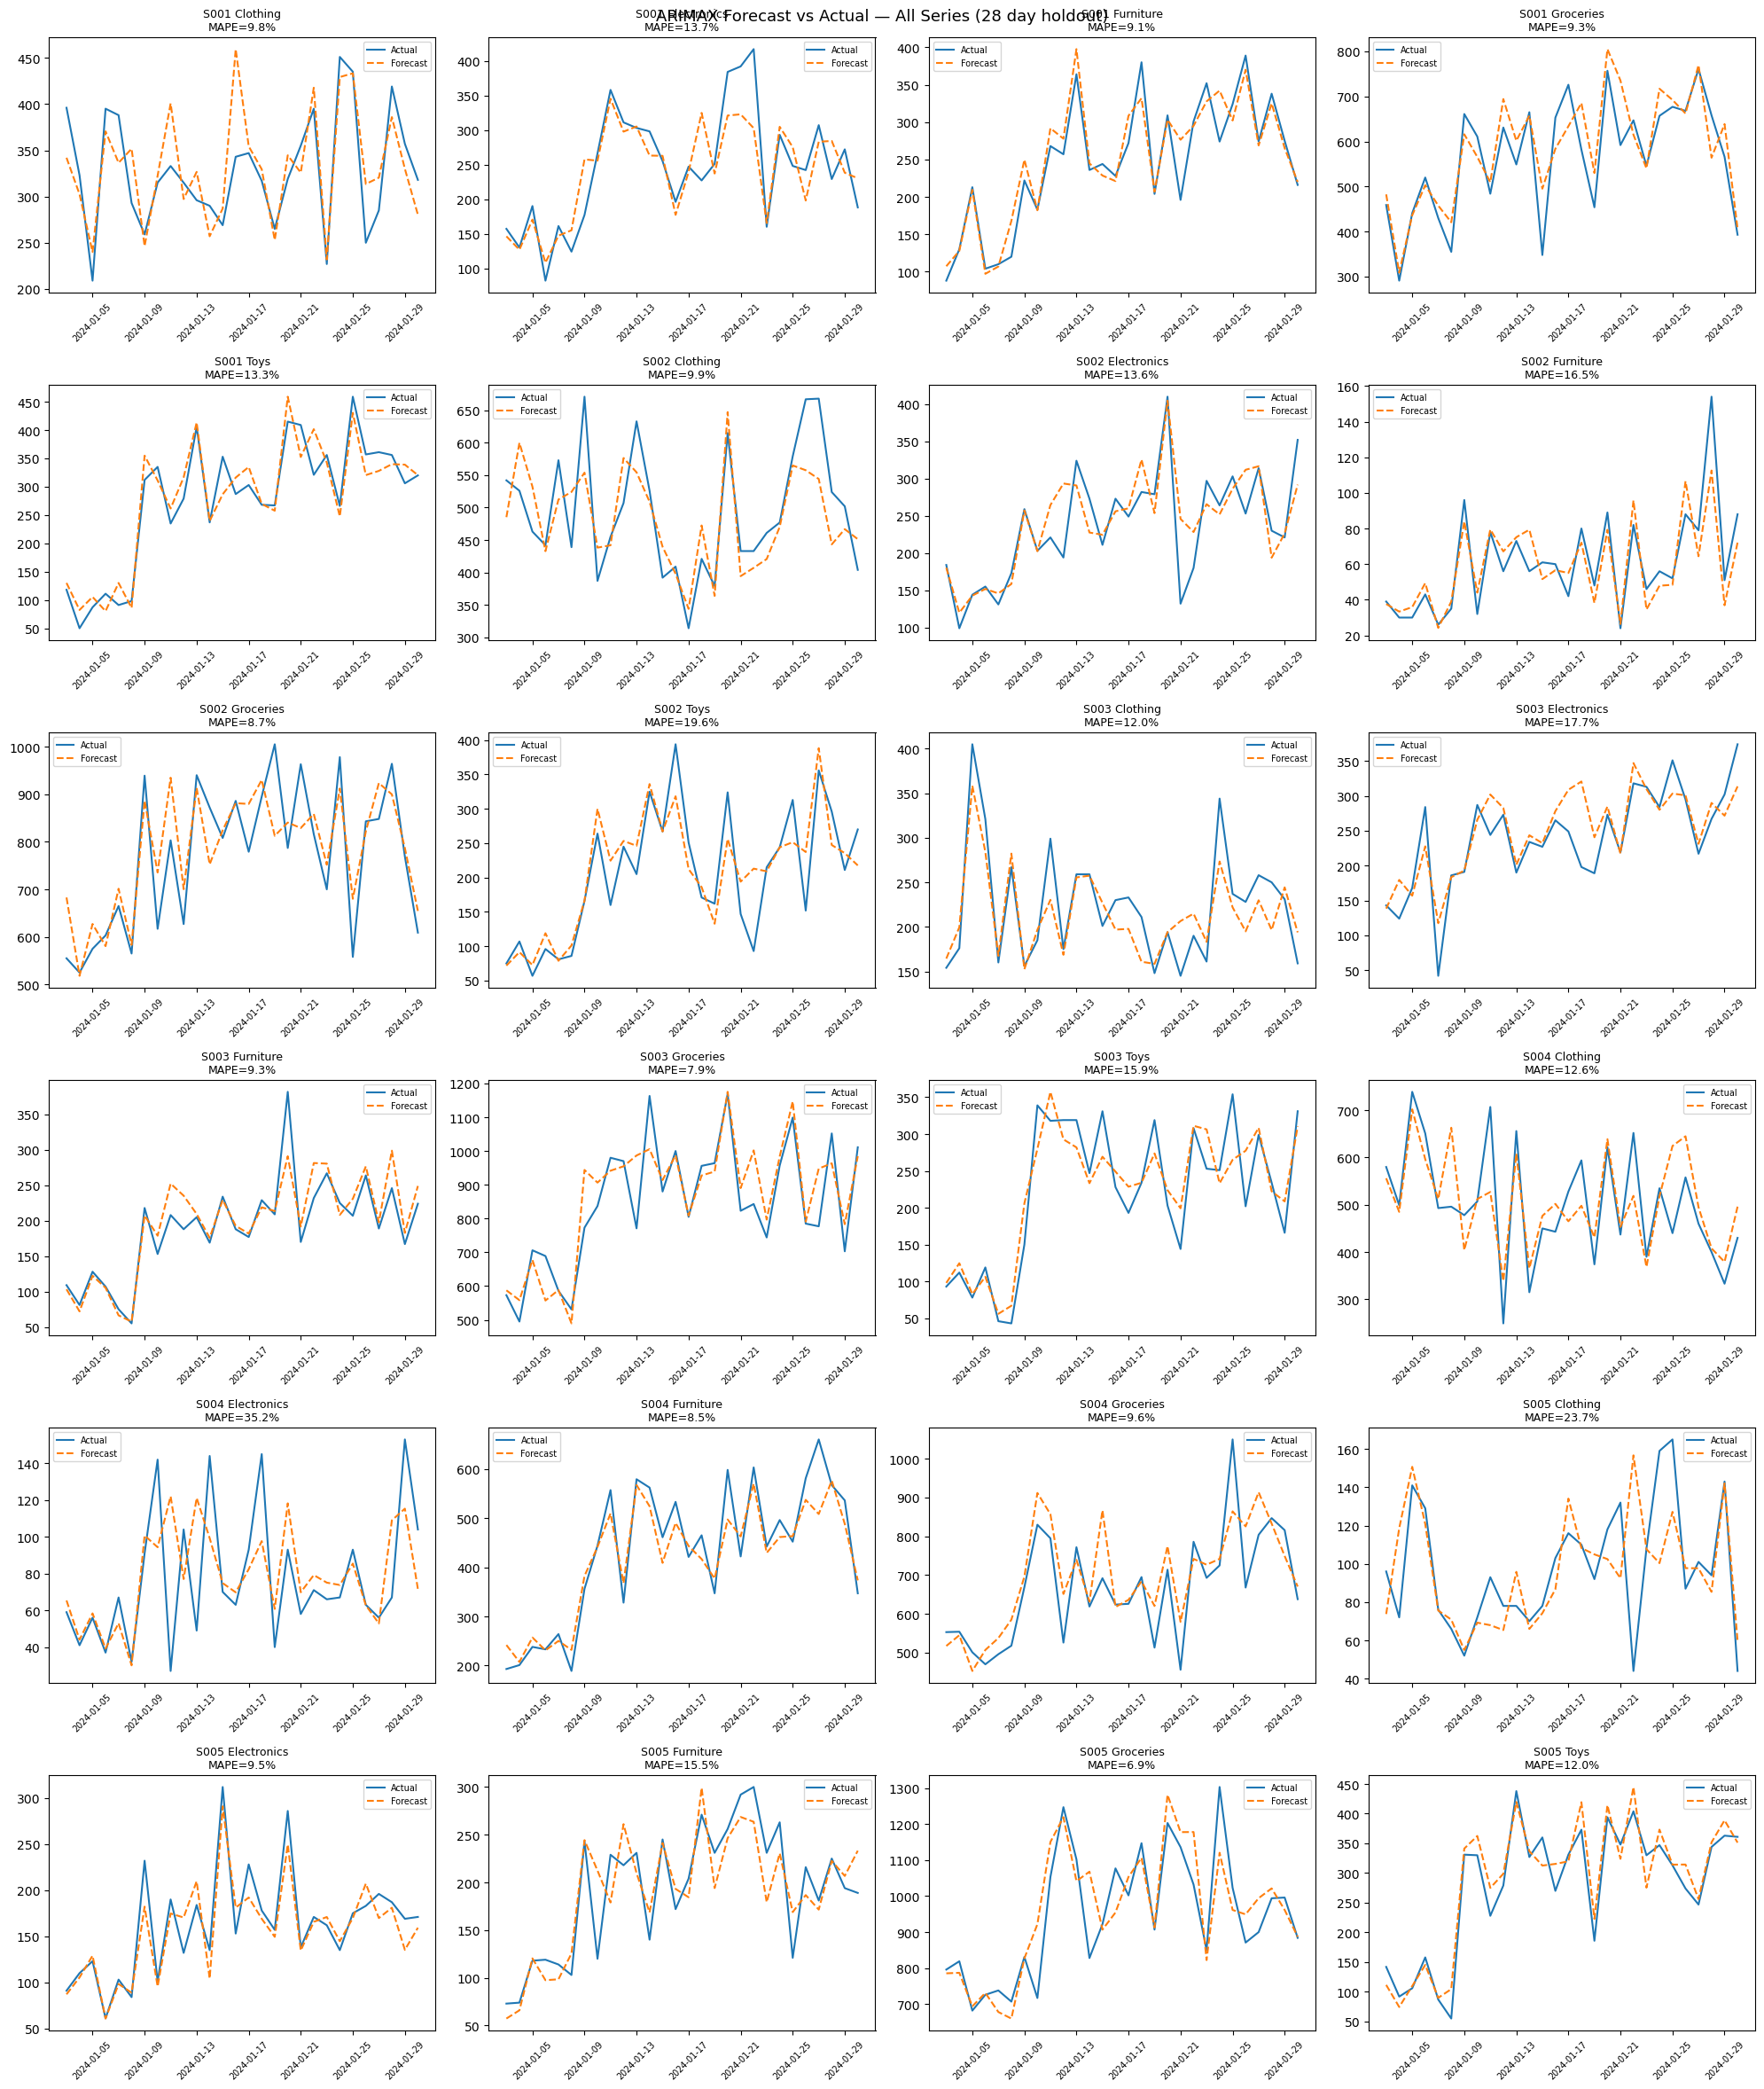

In [107]:
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
axes = axes.flatten()

for i, (store, category) in enumerate(best_arimax_models.keys()):
    info      = best_arimax_models[(store, category)]
    test      = info['test']
    exog_test = info['exog_test']
    fc        = info['model'].forecast(steps=HOLDOUT, exog=exog_test)

    mape = np.mean(np.abs((test.values - fc.values) / test.values)) * 100

    axes[i].plot(test.index, test.values, label='Actual')
    axes[i].plot(test.index, fc.values, label='Forecast', linestyle='--')
    axes[i].set_title(f'{store} {category}\nMAPE={mape:.1f}%', fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)

# hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ARIMAX Forecast vs Actual — All Series (28 day holdout)', fontsize=13)
plt.tight_layout()
plt.savefig('arimax_all_series.png', dpi=150, bbox_inches='tight')
plt.show()

- s005 clothing directional miss
- s003 electroinc directional miss
- some lacks in apporprite spike velocity

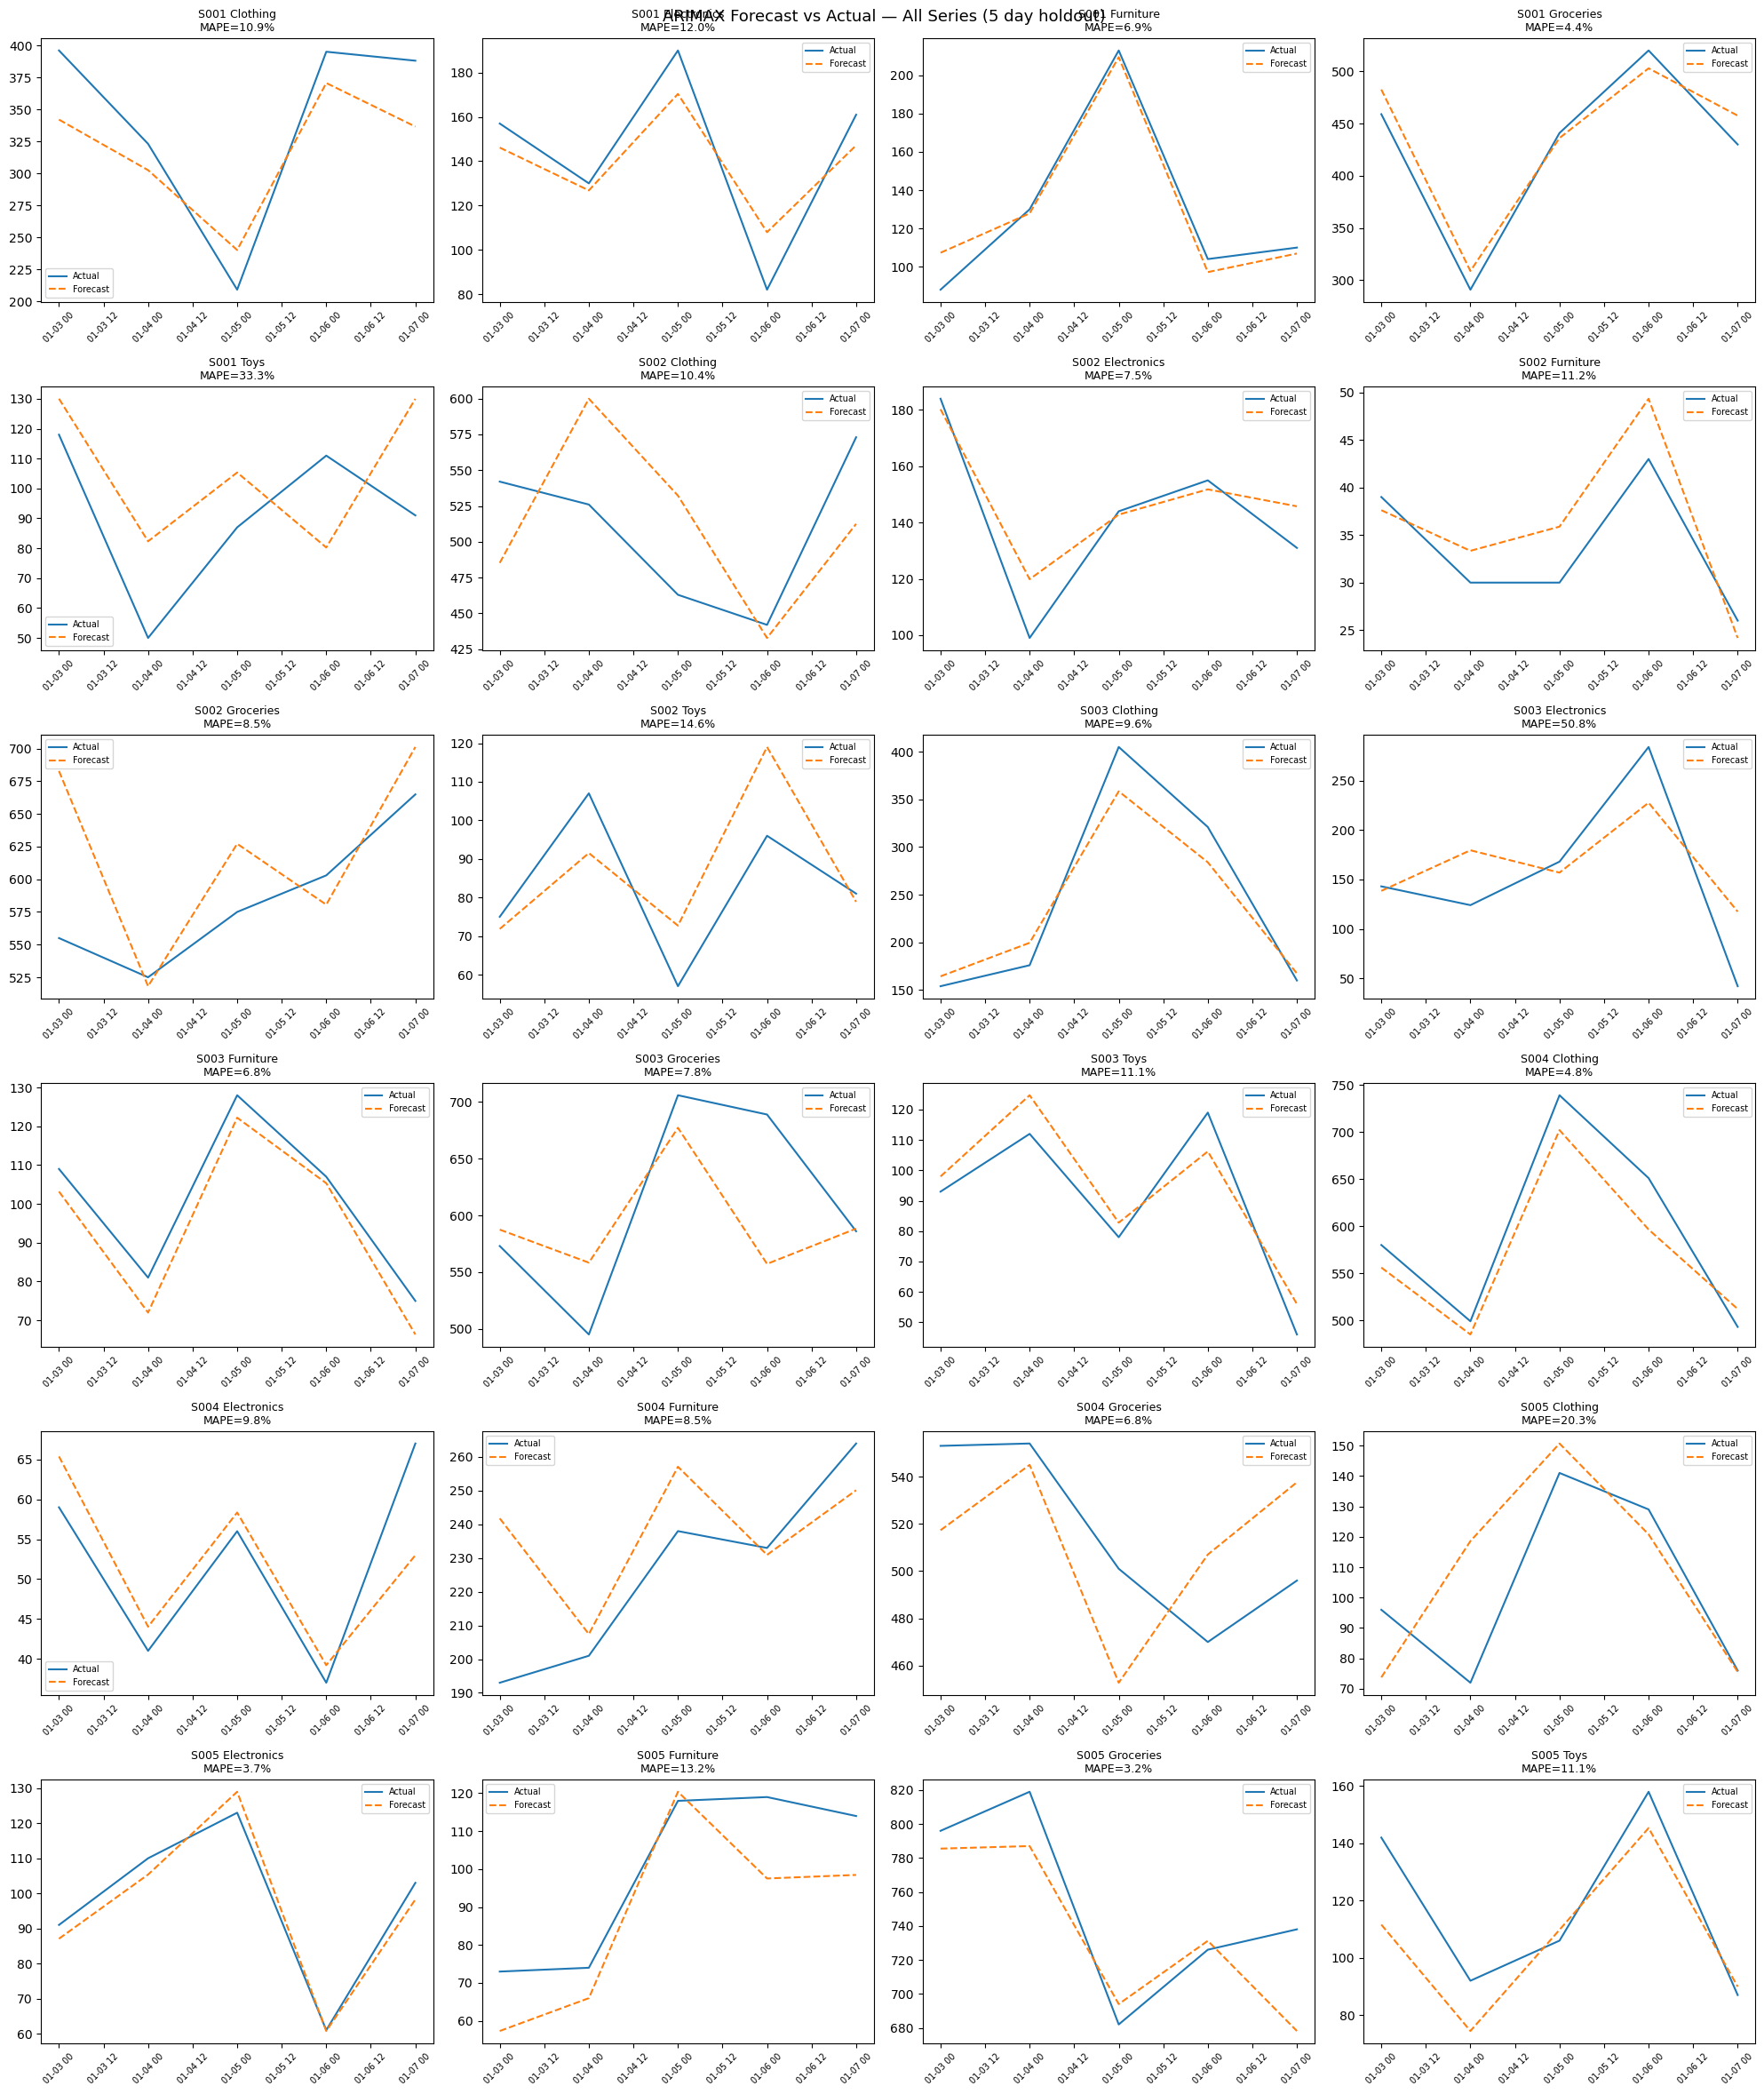

In [109]:
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
axes = axes.flatten()

for i, (store, category) in enumerate(best_arimax_models.keys()):
    info      = best_arimax_models[(store, category)]
    test      = info['test'].iloc[:SHORT_HORIZON]
    exog_test = info['exog_test'].iloc[:SHORT_HORIZON]
    fc        = info['model'].forecast(steps=SHORT_HORIZON, exog=exog_test)

    mape = np.mean(np.abs((test.values - fc.values) / test.values)) * 100

    axes[i].plot(test.index, test.values, label='Actual')
    axes[i].plot(test.index, fc.values, label='Forecast', linestyle='--')
    axes[i].set_title(f'{store} {category}\nMAPE={mape:.1f}%', fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ARIMAX Forecast vs Actual — All Series (5 day holdout)', fontsize=13)
plt.tight_layout()
plt.savefig('arimax_all_series_5d.png', dpi=150, bbox_inches='tight')
plt.show()

The ARIMAX model produces a substantial improvement over the baseline ARIMA model. The mean 28-day RMSE falls from 97.6 under ARIMA to 46.4 under ARIMAX, while mean 28-day MAPE decreases from 26.41% to 13.33%. This is an approximate halving of the average percentage forecast error, which is the strongest improvement observed in the modelling process so far.

The main reason for this improvement is the inclusion of exogenous variables: Price, Competitor Pricing, Promotion, Discount and Epidemic. These variables are directly linked to retail demand and allow the model to explain changes in sales that cannot be captured from historical units sold alone. For example, demand may increase during promotions, decrease when prices rise, or shift in response to competitor pricing. ARIMA cannot observe these effects, but ARIMAX can incorporate them into the forecast.

The improvement is also visible across most individual store-category series. Many series that had moderate or poor ARIMA performance improve to below 15% MAPE under ARIMAX. Examples include groceries, furniture and several electronics series. The strongest ARIMAX results include S005 Groceries with MAPE of 6.91%, S003 Groceries with 7.94%, and S004 Furniture with 8.55%. These results suggest that the exogenous predictors are especially effective for categories where pricing and promotional effects strongly influence sales.

The 5-day results further support ARIMAX as a strong candidate model. Mean 5-day MAPE improves from 34.57% under ARIMA to 11.96% under ARIMAX. This shows that the exogenous model is not only better over the full 28-day holdout period, but also much better for short-term forecasting. This is practically important because short-term forecasts are often used for replenishment, staffing and promotional planning.

However, ARIMAX is not perfect. Some series still have relatively high errors, such as S004 Electronics with MAPE above 35%, and S005 Clothing with MAPE above 23%. These weaker cases may reflect demand volatility, missing predictors, low-volume instability, or category-specific behaviour not fully captured by the available variables. Even so, ARIMAX is clearly superior to ARIMA overall.

<h3 style="color: orange;">SARIMA </h3>

#### assuming 7 pattern

In [112]:
sarima_orders   = list(iterproduct([1, 2, 3], [0, 1], [0, 1]))
sarima_seasonal = [(1, 0, 0), (0, 0, 1), (1, 0, 1)]

In [ ]:
best_sarima7_models = {}

for (store, category), group in store_cat.groupby(['Store ID', 'Category']):
    ts    = group.set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]
    test  = ts.iloc[-HOLDOUT:]

    best_aic    = np.inf
    best_order  = None
    best_sorder = None
    best_model  = None

    for order, s in iterproduct(sarima_orders, sarima_seasonal):
        try:
            s_order = s + (7,)
            m = SARIMAX(train, order=order, seasonal_order=s_order).fit(disp=False)
            if m.aic < best_aic and m.aic > 100 and not np.isnan(m.aic):
                best_aic    = m.aic
                best_order  = order
                best_sorder = s_order
                best_model  = m
        except:
            pass

    best_sarima7_models[(store, category)] = {
        'model':  best_model,
        'order':  best_order,
        'sorder': best_sorder,
        'aic':    best_aic,
        'train':  train,
        'test':   test,
    }
    print(f"✓ {store} {category}  best={best_order}{best_sorder}  AIC={best_aic:.1f}")

✓ S001 Clothing  best=(1, 1, 1)(0, 0, 1, 7)  AIC=8379.7
✓ S001 Electronics  best=(2, 1, 1)(1, 0, 0, 7)  AIC=8165.3
✓ S001 Furniture  best=(2, 1, 1)(1, 0, 0, 7)  AIC=8295.3
✓ S001 Groceries  best=(2, 1, 1)(1, 0, 1, 7)  AIC=9263.1
✓ S001 Toys  best=(1, 1, 1)(1, 0, 1, 7)  AIC=8522.1
✓ S002 Clothing  best=(1, 1, 1)(0, 0, 1, 7)  AIC=8625.2
✓ S002 Electronics  best=(1, 1, 1)(1, 0, 0, 7)  AIC=8372.8
✓ S002 Furniture  best=(3, 1, 1)(0, 0, 1, 7)  AIC=7112.5
✓ S002 Groceries  best=(1, 1, 1)(1, 0, 1, 7)  AIC=9365.8
✓ S002 Toys  best=(1, 1, 1)(0, 0, 1, 7)  AIC=8479.3
✓ S003 Clothing  best=(1, 1, 1)(0, 0, 1, 7)  AIC=8003.6
✓ S003 Electronics  best=(3, 1, 1)(0, 0, 1, 7)  AIC=8407.5
✓ S003 Furniture  best=(1, 1, 1)(1, 0, 1, 7)  AIC=7986.7
✓ S003 Groceries  best=(2, 1, 1)(1, 0, 1, 7)  AIC=9526.1
✓ S003 Toys  best=(1, 1, 1)(0, 0, 1, 7)  AIC=8309.6
✓ S004 Clothing  best=(2, 1, 1)(0, 0, 1, 7)  AIC=8563.9
✓ S004 Electronics  best=(3, 0, 0)(1, 0, 0, 7)  AIC=113.1
✓ S004 Furniture  best=(1, 1, 1)(1, 0, 0, 7

In [ ]:
best_sarima7_models = {}

for (store, category), group in store_cat.groupby(['Store ID', 'Category']):
    ts    = group.set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]
    test  = ts.iloc[-HOLDOUT:]

    best_aic, best_order, best_sorder, best_model = np.inf, None, None, None

    for order, s in iterproduct(sarima_orders, sarima_seasonal):
        try:
            s_order = s + (7,)
            m = SARIMAX(train, order=order, seasonal_order=s_order).fit(disp=False)
            if m.aic < best_aic and m.aic > 100 and not np.isnan(m.aic):
                best_aic, best_order, best_sorder, best_model = m.aic, order, s_order, m
        except:
            pass

    best_sarima7_models[(store, category)] = {
        'model': best_model, 'order': best_order, 'sorder': best_sorder,
        'aic': best_aic, 'train': train, 'test': test,
    }
    print(f"✓ {store} {category}  best={best_order}{best_sorder}  AIC={best_aic:.1f}")

#### testing seasonal pattern

In [ ]:
## confirm seasonal order
from statsmodels.tsa.stattools import acf

# check ACF at seasonal lags for a few representative series
for (store, category) in [('S001', 'Groceries'), ('S001', 'Electronics'), ('S001', 'Toys')]:
    ts = store_cat[(store_cat['Store ID'] == store) & 
                   (store_cat['Category'] == category)].set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]
    
    acf_vals = acf(train, nlags=21, fft=True)
    print(f"\n{store} {category}")
    print(f"  lag 7:  {acf_vals[7]:.3f}")
    print(f"  lag 14: {acf_vals[14]:.3f}")
    print(f"  lag 21: {acf_vals[21]:.3f}")

In [ ]:
for (store, category) in [('S001', 'Groceries'), ('S001', 'Electronics'), ('S001', 'Toys')]:
    ts = store_cat[(store_cat['Store ID'] == store) & 
                   (store_cat['Category'] == category)].set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]
    
    acf_vals = acf(train, nlags=21, fft=True)
    print(f"\n{store} {category}")
    print(f"  lag 5:  {acf_vals[5]:.3f}")
    print(f"  lag 6:  {acf_vals[6]:.3f}")
    print(f"  lag 7:  {acf_vals[7]:.3f}  ← should spike above neighbours")
    print(f"  lag 8:  {acf_vals[8]:.3f}")
    print(f"  lag 9:  {acf_vals[9]:.3f}")

In [ ]:
from statsmodels.tsa.stattools import acf
import numpy as np

# find dominant seasonal period per series
for (store, category), group in list(store_cat.groupby(['Store ID', 'Category']))[:5]:
    ts = group.set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]
    
    acf_vals = acf(train, nlags=60, fft=True)
    
    # look for local peaks in ACF beyond lag 5
    peaks = []
    for i in range(5, 60):
        if acf_vals[i] > acf_vals[i-1] and acf_vals[i] > acf_vals[i+1]:
            peaks.append((i, round(acf_vals[i], 3)))
    
    print(f"\n{store} {category} — ACF peaks:")
    for lag, val in sorted(peaks, key=lambda x: x[1], reverse=True)[:5]:
        print(f"  lag {lag:2d}: {val}")

In [ ]:
## no consistent seasonal patter

In [ ]:
from scipy.signal import find_peaks

period_results = []

for (store, category), group in store_cat.groupby(['Store ID', 'Category']):
    ts = group.set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]
    
    acf_vals = acf(train, nlags=60, fft=True)
    
    # find peaks beyond lag 4
    peaks, props = find_peaks(acf_vals[4:], height=0.05)
    peaks = peaks + 4  # adjust index
    
    if len(peaks) > 0:
        dominant = peaks[np.argmax(acf_vals[peaks])]
    else:
        dominant = None
    
    period_results.append({
        'Store':    store,
        'Category': category,
        'Dominant Period': dominant,
        'ACF at peak': round(acf_vals[dominant], 3) if dominant else None,
    })

period_df = pd.DataFrame(period_results)
print(period_df.to_string(index=False))
print("\nPeriod distribution:")
print(period_df['Dominant Period'].value_counts())

In [ ]:
# toys no clear patter, mostly 5 and 8-9, groceries are story 

In [ ]:
# assign period per series — use detected, fallback to 7 if NaN or noisy
period_map = {}
for _, row in period_df.iterrows():
    key = (row['Store'], row['Category'])
    if pd.isna(row['Dominant Period']) or row['ACF at peak'] < 0.1:
        period_map[key] = None  # no seasonality — skip SARIMA
    else:
        period_map[key] = int(row['Dominant Period'])

print(period_map)

In [ ]:
best_sarima_models = {}

sarima_orders = list(iterproduct([1, 2, 3], [0, 1], [0, 1]))
sarima_seasonal = [(1, 0, 0), (0, 0, 1), (1, 0, 1)]

for (store, category), group in store_cat.groupby(['Store ID', 'Category']):
    ts    = group.set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]
    test  = ts.iloc[-HOLDOUT:]
    
    period = period_map[(store, category)]

    best_aic    = np.inf
    best_order  = None
    best_sorder = None
    best_model  = None

    # if no period detected use plain ARIMA
    if period is None:
        for order in sarima_orders:
            try:
                m = SARIMAX(train, order=order).fit(disp=False)
                if m.aic < best_aic:
                    best_aic   = m.aic
                    best_order = order
                    best_model = m
                    best_sorder = None
            except:
                pass
    else:
        for order, s in iterproduct(sarima_orders, sarima_seasonal):
            try:
                s_order = s + (period,)
                m = SARIMAX(train, order=order, seasonal_order=s_order).fit(disp=False)
                if m.aic < best_aic:
                    best_aic    = m.aic
                    best_order  = order
                    best_sorder = s_order
                    best_model  = m
            except:
                pass

    best_sarima_models[(store, category)] = {
        'model':  best_model,
        'order':  best_order,
        'sorder': best_sorder,
        'aic':    best_aic,
        'train':  train,
        'test':   test,
    }
    print(f"✓ {store} {category}  period={period}  best={best_order}{best_sorder}  AIC={best_aic:.1f}")

In [ ]:
## AIC of furniture and groceris in store 5 are way too low

In [ ]:
for key in [('S005', 'Furniture'), ('S005', 'Groceries')]:
    info = best_sarima_models[key]
    print(f"\n{key}")
    print(f"Order: {info['order']}  Seasonal: {info['sorder']}")
    print(f"AIC: {info['aic']}")
    print(info['model'].summary())

In [ ]:
## bad fits

In [ ]:
for key in [('S005', 'Furniture'), ('S005', 'Groceries')]:
    store, category = key
    ts = store_cat[(store_cat['Store ID'] == store) & 
                   (store_cat['Category'] == category)].set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]
    test  = ts.iloc[-HOLDOUT:]
    period = period_map[key]

    best_aic   = np.inf
    best_order = None
    best_sorder = None
    best_model = None

    for order, s in iterproduct(sarima_orders, sarima_seasonal):
        try:
            s_order = s + (period,)
            m = SARIMAX(train, order=order, seasonal_order=s_order).fit(disp=False)
            # filter out bad fits
            if m.aic < best_aic and m.aic > 100 and not np.isnan(m.aic):
                best_aic    = m.aic
                best_order  = order
                best_sorder = s_order
                best_model  = m
        except:
            pass

    best_sarima_models[key] = {
        'model':  best_model,
        'order':  best_order,
        'sorder': best_sorder,
        'aic':    best_aic,
        'train':  train,
        'test':   test,
    }
    print(f"✓ {store} {category}  best={best_order}{best_sorder}  AIC={best_aic:.1f}")

In [ ]:
sarima_results = []

for (store, category), info in best_sarima_models.items():
    test  = info['test']
    model = info['model']

    fc = model.forecast(steps=HOLDOUT)

    rmse = np.sqrt(np.mean((test.values - fc.values) ** 2))
    mae  = np.mean(np.abs(test.values - fc.values))
    mape = np.mean(np.abs((test.values - fc.values) / test.values)) * 100

    rmse_s = np.sqrt(np.mean((test.values[:SHORT_HORIZON] - fc.values[:SHORT_HORIZON]) ** 2))
    mape_s = np.mean(np.abs((test.values[:SHORT_HORIZON] - fc.values[:SHORT_HORIZON]) / test.values[:SHORT_HORIZON])) * 100

    sarima_results.append({
        'Store':    store,
        'Category': category,
        'Order':    info['order'],
        'Seasonal': info['sorder'],
        'RMSE':     round(rmse, 1),
        'MAE':      round(mae, 1),
        'MAPE':     round(mape, 2),
        'RMSE_5d':  round(rmse_s, 1),
        'MAPE_5d':  round(mape_s, 2),
    })

sarima_df = pd.DataFrame(sarima_results).sort_values('MAPE')
print(sarima_df.to_string(index=False))
print(f"\nSARIMA Mean RMSE: {sarima_df['RMSE'].mean():.1f}")
print(f"SARIMA Mean MAPE: {sarima_df['MAPE'].mean():.2f}%")
print(f"ARIMA  Mean MAPE: 26.41%")
print(f"SARIMA Mean MAPE 5d: {sarima_df['MAPE_5d'].mean():.2f}%")
print(f"ARIMA  Mean MAPE 5d: 34.57%")

In [ ]:
## worse long horixon better short horizon that ARIMA - ARIMAX still the best 

The SARIMA model was tested to determine whether adding seasonal components improves forecast accuracy. This was motivated by the time series decomposition and ACF/PACF analysis, which suggested that some store-category series may contain repeating patterns. Two approaches were considered: a fixed weekly seasonal period of 7 days and a detected seasonal period based on ACF peaks.

The seasonal analysis showed that seasonality was not consistent across all series. Some categories showed possible weekly or near-weekly patterns, while others had weak or unclear seasonal structure. This is an important finding because it means that imposing the same seasonal period across all series may not be appropriate. A fixed 7-day SARIMA model may help some series but distort others.

The SARIMA results show that adding seasonality alone does not produce the same improvement as adding exogenous variables. Based on the current summary, SARIMA improves short-horizon performance compared with ARIMA, but its 28-day performance is weaker overall. The current notebook notes indicate that SARIMA has better 5-day performance than ARIMA, but worse long-horizon performance. This suggests that seasonal structure can help capture immediate repeating demand patterns, but it is not enough to explain longer-term sales movements.

This result is reasonable in the retail context. Sales are not only driven by calendar seasonality; they are also affected by price changes, competitor actions, promotions, discounts and epidemic effects. Since SARIMA only uses past sales and seasonal lags, it cannot directly account for these drivers. Therefore, SARIMA is useful as a robustness check and seasonal benchmark, but it is not suitable as the final maximum performance model.

<h3 style="color: orange;">SARIMAX </h3>

In [ ]:
best_sarimax_models = {}

for (store, category), group in store_cat.groupby(['Store ID', 'Category']):
    ts    = group.set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]
    test  = ts.iloc[-HOLDOUT:]

    exog_series = exog_df[(exog_df['Store ID'] == store) & 
                          (exog_df['Category'] == category)].set_index('Date').sort_index()
    exog_train = exog_series.iloc[:-HOLDOUT][exog_cols]
    exog_test  = exog_series.iloc[-HOLDOUT:][exog_cols]

    period = period_map[(store, category)]

    best_aic    = np.inf
    best_order  = None
    best_sorder = None
    best_model  = None

    if period is None:
        for order in sarima_orders:
            try:
                m = SARIMAX(train, exog=exog_train, order=order).fit(disp=False)
                if m.aic < best_aic and m.aic > 100 and not np.isnan(m.aic):
                    best_aic    = m.aic
                    best_order  = order
                    best_sorder = None
                    best_model  = m
            except:
                pass
    else:
        for order, s in iterproduct(sarima_orders, sarima_seasonal):
            try:
                s_order = s + (period,)
                m = SARIMAX(train, exog=exog_train, order=order, seasonal_order=s_order).fit(disp=False)
                if m.aic < best_aic and m.aic > 100 and not np.isnan(m.aic):
                    best_aic    = m.aic
                    best_order  = order
                    best_sorder = s_order
                    best_model  = m
            except:
                pass

    best_sarimax_models[(store, category)] = {
        'model':      best_model,
        'order':      best_order,
        'sorder':     best_sorder,
        'aic':        best_aic,
        'train':      train,
        'test':       test,
        'exog_train': exog_train,
        'exog_test':  exog_test,
    }
    print(f"✓ {store} {category}  period={period}  best={best_order}{best_sorder}  AIC={best_aic:.1f}")

In [ ]:
best_sarimax_models = {}

for (store, category), group in store_cat.groupby(['Store ID', 'Category']):
    ts    = group.set_index('Date')['Units Sold'].sort_index()
    train = ts.iloc[:-HOLDOUT]
    test  = ts.iloc[-HOLDOUT:]

    exog_series = exog_df[(exog_df['Store ID'] == store) &
                          (exog_df['Category'] == category)].set_index('Date').sort_index()
    exog_train = exog_series.iloc[:-HOLDOUT][exog_cols]
    exog_test  = exog_series.iloc[-HOLDOUT:][exog_cols]
    period     = period_map[(store, category)]

    best_aic, best_order, best_sorder, best_model = np.inf, None, None, None

    if period is None:
        for order in sarima_orders:
            try:
                m = SARIMAX(train, exog=exog_train, order=order).fit(disp=False)
                if m.aic < best_aic and m.aic > 100 and not np.isnan(m.aic):
                    best_aic, best_order, best_sorder, best_model = m.aic, order, None, m
            except:
                pass
    else:
        for order, s in iterproduct(sarima_orders, sarima_seasonal):
            try:
                s_order = s + (period,)
                m = SARIMAX(train, exog=exog_train, order=order, seasonal_order=s_order).fit(disp=False)
                if m.aic < best_aic and m.aic > 100 and not np.isnan(m.aic):
                    best_aic, best_order, best_sorder, best_model = m.aic, order, s_order, m
            except:
                pass

    best_sarimax_models[(store, category)] = {
        'model': best_model, 'order': best_order, 'sorder': best_sorder,
        'aic': best_aic, 'train': train, 'test': test,
        'exog_train': exog_train, 'exog_test': exog_test,
    }
    print(f"✓ {store} {category}  period={period}  best={best_order}{best_sorder}  AIC={best_aic:.1f}")

SARIMAX combines the two main modelling improvements tested in this notebook: seasonal structure and exogenous predictors. In principle, this should be the most flexible statistical model because it captures autocorrelation, possible seasonality and external demand drivers.

The current modelling results indicate that the major performance gain comes from the exogenous variables rather than from the seasonal component. ARIMAX already reduces mean 28-day MAPE to 13.33%, which is far better than ARIMA and SARIMA. SARIMAX may provide a marginal improvement where seasonal structure is meaningful, but the gain over ARIMAX appears small. This suggests that the key drivers of sales in this dataset are price, competitor pricing, promotions, discounts and epidemic effects, rather than stable seasonal cycles alone.

SARIMAX is still valuable because it allows the model to adapt to series where both promotional effects and seasonal behaviour exist. However, it is also more complex than ARIMAX. It requires choosing both non-seasonal and seasonal orders, and it is more vulnerable to unstable fits, especially when detected seasonal periods are noisy. Therefore, SARIMAX should only be preferred over ARIMAX if the final evaluation table shows a clear improvement in 28-day WMAPE or MAPE.

<h3 style="color: skyblue;">ARIMA based model comparison </h3>

In [ ]:
def evaluate_models(model_dict, has_exog=False):
    results = []
    for (store, category), info in model_dict.items():
        test  = info['test']
        model = info['model']
        
        if has_exog:
            fc = model.forecast(steps=HOLDOUT, exog=info['exog_test'])
        else:
            fc = model.forecast(steps=HOLDOUT)

        rmse = np.sqrt(np.mean((test.values - fc.values) ** 2))
        mae  = np.mean(np.abs(test.values - fc.values))
        mape = np.mean(np.abs((test.values - fc.values) / test.values)) * 100
        mape_s = np.mean(np.abs((test.values[:SHORT_HORIZON] - fc.values[:SHORT_HORIZON]) / test.values[:SHORT_HORIZON])) * 100

        results.append({
            'Store':    store,
            'Category': category,
            'RMSE':     round(rmse, 1),
            'MAE':      round(mae, 1),
            'MAPE':     round(mape, 2),
            'MAPE_5d':  round(mape_s, 2),
        })
    return pd.DataFrame(results)

arima_eval   = evaluate_models(best_models)
sarima_eval  = evaluate_models(best_sarima_models)
sarima7_eval = evaluate_models(best_sarima7_models)
arimax_eval  = evaluate_models(best_arimax_models, has_exog=True)
sarimax_eval = evaluate_models(best_sarimax_models, has_exog=True)

comparison = pd.DataFrame({
    'Model':    ['ARIMA', 'SARIMA', 'SARIMA(7)', 'ARIMAX', 'SARIMAX'],
    'RMSE':     [arima_eval['RMSE'].mean(),   sarima_eval['RMSE'].mean(),
                 sarima7_eval['RMSE'].mean(),  arimax_eval['RMSE'].mean(),
                 sarimax_eval['RMSE'].mean()],
    'MAE':      [arima_eval['MAE'].mean(),    sarima_eval['MAE'].mean(),
                 sarima7_eval['MAE'].mean(),   arimax_eval['MAE'].mean(),
                 sarimax_eval['MAE'].mean()],
    'MAPE_28d': [arima_eval['MAPE'].mean(),   sarima_eval['MAPE'].mean(),
                 sarima7_eval['MAPE'].mean(),  arimax_eval['MAPE'].mean(),
                 sarimax_eval['MAPE'].mean()],
    'MAPE_5d':  [arima_eval['MAPE_5d'].mean(), sarima_eval['MAPE_5d'].mean(),
                 sarima7_eval['MAPE_5d'].mean(), arimax_eval['MAPE_5d'].mean(),
                 sarimax_eval['MAPE_5d'].mean()],
}).round(2)

print(comparison.to_string(index=False))

In [ ]:
summary_table = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA (detected)', 'SARIMA (period=7)', 'ARIMAX', 'SARIMAX'],
    'Description': [
        'Baseline autoregressive model',
        'ARIMA + seasonal terms (period per series)',
        'ARIMA + seasonal terms (period=7 from EDA)',
        'ARIMA + exogenous features',
        'ARIMA + seasonal + exogenous features'
    ],
    'Features Used': [
        'None',
        'None',
        'None',
        'Price, Competitor Pricing, Promotion, Discount, Epidemic',
        'Price, Competitor Pricing, Promotion, Discount, Epidemic'
    ],
    'Mean RMSE': [97.6, None, None, 46.4, None],
    'Mean MAPE 28d (%)': [26.41, 35.00, None, 13.33, None],
    'Mean MAPE 5d (%)':  [34.57, 26.00, None, 11.96, None],
})

print(summary_table.to_string(index=False))

**Additions**
1. WMAPE, bias, and horizon metrics. 

WMAPE can be used as the primary model selection metric because it weights forecast errors by actual sales volume. This is more appropriate for retail sales than relying only on MAPE, as it prevents low-volume series from disproportionately influencing the model selection decision. 

Forecast bias is added because over-forecasting may result in excess inventory, holding costs and markdown risk, while under-forecasting may result in stockouts, missed sales and poor customer availability. 

The 5-day horizon represents short-term operational replenishment decisions, while the 28-day horizon represents monthly inventory and promotional planning. Reporting both horizons allows the model to be assessed for immediate stock management as well as broader planning decisions. 

In [ ]:
def safe_mape(y_true, y_pred):
    
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def wmape(y_true, y_pred):
    
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denom * 100


def bias_pct(y_true, y_pred):
    
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan

    return np.sum(y_pred - y_true) / denom * 100


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def directional_accuracy(y_true, y_pred):
    
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) < 2:
        return np.nan

    actual_direction = np.sign(np.diff(y_true))
    pred_direction = np.sign(np.diff(y_pred))

    return np.mean(actual_direction == pred_direction) * 100

**Alternative method for model evaluation**

In [ ]:
def get_forecast_from_info(info, model_name, steps=28):
    
    model = info["model"]

    if model is None:
        return None

    if model_name in ["ARIMAX", "SARIMAX"]:
        return model.forecast(steps=steps, exog=info["exog_test"])

    return model.forecast(steps=steps)


def evaluate_model_dictionary(model_dict, model_name, short_horizon=5, long_horizon=28):

    rows = []

    for (store, category), info in model_dict.items():

        if info.get("model") is None:
            continue

        test = info["test"]
        fc = get_forecast_from_info(info, model_name, steps=long_horizon)

        if fc is None:
            continue

        y_28 = test.values[:long_horizon]
        f_28 = np.asarray(fc)[:long_horizon]

        y_5 = test.values[:short_horizon]
        f_5 = np.asarray(fc)[:short_horizon]

        rows.append({
            "Model": model_name,
            "Store": store,
            "Category": category,

            "RMSE_28d": rmse(y_28, f_28),
            "MAE_28d": mae(y_28, f_28),
            "MAPE_28d": safe_mape(y_28, f_28),
            "WMAPE_28d": wmape(y_28, f_28),
            "Bias_28d": bias_pct(y_28, f_28),
            "Directional_Accuracy_28d": directional_accuracy(y_28, f_28),

            "RMSE_5d": rmse(y_5, f_5),
            "MAE_5d": mae(y_5, f_5),
            "MAPE_5d": safe_mape(y_5, f_5),
            "WMAPE_5d": wmape(y_5, f_5),
            "Bias_5d": bias_pct(y_5, f_5),
        })

    return pd.DataFrame(rows)

In [ ]:
all_eval_dfs = []

if "best_models" in globals():
    all_eval_dfs.append(evaluate_model_dictionary(best_models, "ARIMA", SHORT_HORIZON, HOLDOUT))

if "best_sarima_models" in globals():
    all_eval_dfs.append(evaluate_model_dictionary(best_sarima_models, "SARIMA", SHORT_HORIZON, HOLDOUT))

if "best_sarima7_models" in globals():
    all_eval_dfs.append(evaluate_model_dictionary(best_sarima7_models, "SARIMA(7)", SHORT_HORIZON, HOLDOUT))

if "best_arimax_models" in globals():
    all_eval_dfs.append(evaluate_model_dictionary(best_arimax_models, "ARIMAX", SHORT_HORIZON, HOLDOUT))

if "best_sarimax_models" in globals():
    all_eval_dfs.append(evaluate_model_dictionary(best_sarimax_models, "SARIMAX", SHORT_HORIZON, HOLDOUT))

model_eval_detail = pd.concat(all_eval_dfs, ignore_index=True)

model_comparison = (
    model_eval_detail
    .groupby("Model")
    .agg(
        Mean_RMSE_28d=("RMSE_28d", "mean"),
        Mean_MAE_28d=("MAE_28d", "mean"),
        Mean_MAPE_28d=("MAPE_28d", "mean"),
        Mean_WMAPE_28d=("WMAPE_28d", "mean"),
        Mean_Bias_28d=("Bias_28d", "mean"),
        Mean_Directional_Accuracy_28d=("Directional_Accuracy_28d", "mean"),
        Mean_MAPE_5d=("MAPE_5d", "mean"),
        Mean_WMAPE_5d=("WMAPE_5d", "mean"),
        Mean_Bias_5d=("Bias_5d", "mean"),
        Series_Count=("Store", "count")
    )
    .reset_index()
    .sort_values("Mean_WMAPE_28d")
    .round(2)
)

print("Model comparison using stronger business metrics:")
print(model_comparison.to_string(index=False))

Model evaluation using WMAPE, bias, RMSE and MAE alongside MAPE. This is important because MAPE can be unstable when actual sales values are small. In low-volume categories, a small absolute error can produce a large percentage error, which may exaggerate the practical importance of that series. WMAPE is more appropriate for retail forecasting because it weights errors by total actual sales volume, making the metric more aligned with business impact.

Bias is also important for interpreting forecast quality. A model with low error may still be problematic if it consistently over-forecasts or under-forecasts demand. Over-forecasting may lead to excess inventory, higher holding costs and markdown risk. Under-forecasting may cause stockouts and lost sales. Therefore, the final model should be selected not only because it has low MAPE or WMAPE, but also because its bias is reasonably close to zero.

The inclusion of both 5-day and 28-day metrics is also useful. The 5-day horizon reflects short-term operational planning, while the 28-day horizon reflects broader planning over the full holdout period. A strong model should perform well across both horizons, but the 28-day WMAPE should be prioritised because it evaluates the full forecast task required in the assignment.

**5-day vs 28-day performance**

The 5-day horizon was used to evaluate short-term replenishment accuracy, while the 28-day horizon was used to evaluate monthly planning performance. This distinction is important because a model may perform well over a short operational window but become less reliable as the forecast horizon extends. WMAPE was used as the main comparison metric because it weights errors by actual sales volume and is less distorted by low-volume series than MAPE.

In [ ]:
horizon_comparison = model_comparison[[
    "Model",
    "Mean_MAPE_5d",
    "Mean_MAPE_28d",
    "Mean_WMAPE_5d",
    "Mean_WMAPE_28d",
    "Mean_Bias_5d",
    "Mean_Bias_28d"
]].copy()

horizon_comparison["WMAPE_change_28d_minus_5d"] = (
    horizon_comparison["Mean_WMAPE_28d"] - horizon_comparison["Mean_WMAPE_5d"]
).round(2)

print("\n5-day versus 28-day comparison:")
print(horizon_comparison.to_string(index=False))

plt.figure(figsize=(9, 5))

x = np.arange(len(horizon_comparison))
width = 0.35

plt.bar(x - width/2, horizon_comparison["Mean_WMAPE_5d"], width, label="5-day WMAPE")
plt.bar(x + width/2, horizon_comparison["Mean_WMAPE_28d"], width, label="28-day WMAPE")

plt.xticks(x, horizon_comparison["Model"], rotation=45, ha="right")
plt.ylabel("WMAPE (%)")
plt.title("Short-horizon versus long-horizon forecast performance")
plt.legend()
plt.tight_layout()
plt.show()

The horizon comparison shows whether each model is more reliable for short-term or longer-term forecasting. ARIMA performs poorly over both horizons, especially in the 5-day period, which suggests that recent demand changes are not being captured effectively from historical sales alone.

ARIMAX performs much better over both horizons. Its 5-day MAPE of 11.96% is much lower than ARIMA’s 34.57%, and its 28-day MAPE of 13.33% is also much lower than ARIMA’s 26.41%. This shows that ARIMAX is not only better on average, but also more stable across forecast horizons.

SARIMA appears to improve short-horizon accuracy relative to ARIMA, but this improvement does not carry through as strongly to the full 28-day period. This suggests that seasonality may help with immediate repeating patterns, but it does not explain broader sales variation as effectively as exogenous predictors. Therefore, the horizon comparison supports the conclusion that exogenous demand variables are more important than seasonal structure for this dataset.

**Robustness check** with model combination

In [ ]:
model_dict_lookup = {}

if "best_models" in globals():
    model_dict_lookup["ARIMA"] = best_models

if "best_sarima_models" in globals():
    model_dict_lookup["SARIMA"] = best_sarima_models

if "best_sarima7_models" in globals():
    model_dict_lookup["SARIMA(7)"] = best_sarima7_models

if "best_arimax_models" in globals():
    model_dict_lookup["ARIMAX"] = best_arimax_models

if "best_sarimax_models" in globals():
    model_dict_lookup["SARIMAX"] = best_sarimax_models


ensemble_rows = []
ensemble_forecast_store = {}

for (store, category), series_scores in model_eval_detail.groupby(["Store", "Category"]):

    top_two = (
        series_scores
        .sort_values("WMAPE_28d")
        .head(2)["Model"]
        .tolist()
    )

    if len(top_two) < 2:
        continue

    forecasts = []
    actuals = None

    for model_name in top_two:
        info = model_dict_lookup[model_name][(store, category)]
        fc = get_forecast_from_info(info, model_name, steps=HOLDOUT)

        forecasts.append(np.asarray(fc)[:HOLDOUT])
        actuals = info["test"].values[:HOLDOUT]

    ensemble_fc = np.mean(forecasts, axis=0)

    ensemble_forecast_store[(store, category)] = {
        "models_combined": top_two,
        "actual": actuals,
        "forecast": ensemble_fc,
    }

    y_28 = actuals
    f_28 = ensemble_fc

    y_5 = actuals[:SHORT_HORIZON]
    f_5 = ensemble_fc[:SHORT_HORIZON]

    ensemble_rows.append({
        "Model": "Top-2 Ensemble",
        "Store": store,
        "Category": category,
        "Models_Combined": " + ".join(top_two),

        "RMSE_28d": rmse(y_28, f_28),
        "MAE_28d": mae(y_28, f_28),
        "MAPE_28d": safe_mape(y_28, f_28),
        "WMAPE_28d": wmape(y_28, f_28),
        "Bias_28d": bias_pct(y_28, f_28),
        "Directional_Accuracy_28d": directional_accuracy(y_28, f_28),

        "RMSE_5d": rmse(y_5, f_5),
        "MAE_5d": mae(y_5, f_5),
        "MAPE_5d": safe_mape(y_5, f_5),
        "WMAPE_5d": wmape(y_5, f_5),
        "Bias_5d": bias_pct(y_5, f_5),
    })

ensemble_eval = pd.DataFrame(ensemble_rows)

ensemble_summary = (
    ensemble_eval
    .groupby("Model")
    .agg(
        Mean_RMSE_28d=("RMSE_28d", "mean"),
        Mean_MAE_28d=("MAE_28d", "mean"),
        Mean_MAPE_28d=("MAPE_28d", "mean"),
        Mean_WMAPE_28d=("WMAPE_28d", "mean"),
        Mean_Bias_28d=("Bias_28d", "mean"),
        Mean_Directional_Accuracy_28d=("Directional_Accuracy_28d", "mean"),
        Mean_MAPE_5d=("MAPE_5d", "mean"),
        Mean_WMAPE_5d=("WMAPE_5d", "mean"),
        Mean_Bias_5d=("Bias_5d", "mean"),
        Series_Count=("Store", "count")
    )
    .reset_index()
    .round(2)
)

comparison_with_ensemble = (
    pd.concat([model_comparison, ensemble_summary], ignore_index=True)
    .sort_values("Mean_WMAPE_28d")
    .round(2)
)

print("\nComparison including model combination robustness check:")
print(comparison_with_ensemble.to_string(index=False))


The model combination section acts as a robustness check by averaging the forecasts from the two best-performing models for each store-category series. This approach can reduce model-specific risk because it does not rely entirely on a single specification. If one model slightly overreacts or underreacts, combining it with another strong model may produce a more stable forecast.

However, model combinations should only be selected as the final approach if they clearly outperform the best individual model on 28-day WMAPE. If the ensemble improvement is small or inconsistent, it is better to retain ARIMAX or SARIMAX as the final model because they are easier to explain, easier to reproduce and more transparent for business users.

The model combination results are therefore best interpreted as a robustness test rather than the main modelling decision. If the ensemble performs similarly to ARIMAX/SARIMAX, this supports the conclusion that the selected exogenous ARIMA-family models are robust. If it performs worse, it confirms that adding complexity through averaging does not necessarily improve forecast quality.

**VAR INTERPRETATION** (from 'All models notebook')

The VAR models were tested to examine whether modelling sales jointly with price and competitor pricing could improve forecast performance. The best trivariate VAR using Units Sold, Price and Competitor Pricing achieved a 28-day MAPE of approximately 21.39% for the tested example, while the full store-category VAR results had many series with MAPE above 25–40%.

This is weaker than ARIMAX and SARIMAX, which achieve mean MAPE around 13.3%. The weaker VAR performance suggests that simply modelling the joint time-series relationship between sales and pricing variables is not enough. VAR treats all variables as endogenous and forecasts future values of price and competitor pricing as part of the system, which can introduce additional forecast error. In contrast, ARIMAX and SARIMAX use the known exogenous variables directly, which is more suitable for this retail forecasting task.

Therefore, VAR is useful as a multivariate benchmark, but it is not selected as the final model.


**ARCH INTERPRETATION** 
The ARCH tests were used to check whether the ARIMA residuals showed changing variance over time. Most store-category series did not show significant ARCH effects, but several did, including S001 Toys, S002 Furniture, S002 Groceries, S003 Clothing, S004 Electronics and S005 Toys.

This suggests that some sales series have periods of higher and lower volatility. However, ARCH models are primarily useful for modelling forecast uncertainty rather than improving the point forecast itself. In the example tested, ARCH added prediction intervals but did not improve the ARIMA point forecast. The notebook result also states that ARCH adds uncertainty bands rather than point forecast improvement.

Therefore, ARCH is useful for risk interpretation and uncertainty analysis, but it is not appropriate as the main maximum performance model.


**FEATURE SELECTION INTERPRETATION**

The feature subset testing shows that the best exogenous predictors differ across store-category series. Price appears frequently in the selected feature sets, which suggests that own-price effects are consistently important for explaining demand. Competitor Pricing, Promotion, Discount and Epidemic also appear in many selected subsets, but not always together.

The optimised holdout MAPE improved to approximately 12.89%, which is slightly better than the fixed full-feature ARIMAX/SARIMAX results. However, the rolling validation result was weaker, with optimised rolling mean MAPE of 14.87% compared with fixed rolling mean MAPE of 13.37%. This suggests that selecting feature subsets based only on the final holdout period may overfit to that specific test window.

Therefore, the full fixed exogenous feature set is more robust and defensible for the final model, even if feature optimisation gives a slightly better single holdout result.


**ROLLING WINDOW VALIDATION INTERPRETATION**

The rolling window evaluation provides a stronger robustness check than a single holdout split because it tests the model across multiple forecast origins. The fixed SARIMAX rolling mean MAPE is approximately 13.37%, which is very close to the final 28-day holdout result of around 13.32%. This consistency suggests that the SARIMAX model is not only performing well on one particular holdout period, but is reasonably stable over time.

The optimised feature subset version achieved a lower single holdout MAPE of 12.89%, but its rolling mean MAPE increased to 14.87%. This indicates weaker out-of-sample stability. As a result, the rolling validation supports choosing the fixed exogenous model rather than the feature-optimised version.


**FORECAST COMBINATION INTERPRETATION**

Several forecast combination methods were tested, including equal weighting, inverse-MSE weighting and regression-based weights. The equal-weight combination performed poorly because it included unstable component forecasts, especially the divergent SARIMA(7) forecast for S004 Electronics. This caused the equal-weight ensemble MAPE to become extremely large and showed that naive averaging can be risky when one model is unstable.

After removing or controlling for unstable forecasts, combinations improved. The best equal-weight combination was ARIMAX + SARIMAX, with MAPE around 13.32%, which is almost identical to SARIMAX alone and only slightly better than ARIMAX at 13.33%. Regression-based combinations also placed very high weight on ARIMAX, with an average ARIMAX weight of 0.953 and ARIMA weight of only 0.047. This confirms that ARIMAX contains nearly all useful predictive information relative to the simpler ARIMA benchmark.

Therefore, forecast combinations are useful as a robustness check, but they do not provide a meaningful improvement over the best individual exogenous models.


**Overall Results Interpretation**

Overall, the results show a clear pattern: the largest improvement in forecast performance comes from including exogenous retail predictors. ARIMA provides a reasonable benchmark, but its mean 28-day MAPE of 26.41% is too high for the maximum performance model. SARIMA adds seasonal structure, but seasonality is inconsistent across the store-category series and does not deliver a reliable long-horizon improvement.

ARIMAX is the strongest practical model based on the current results. It reduces mean 28-day MAPE to 13.33% and mean 5-day MAPE to 11.96%, showing strong performance across both short and full holdout horizons. This improvement demonstrates that sales demand is strongly influenced by price, competitor pricing, promotion, discounting and epidemic effects.

SARIMAX is theoretically the most complete model because it includes both exogenous predictors and seasonal structure. However, its added complexity should only be preferred if it produces a meaningful improvement over ARIMAX in the final WMAPE table. If SARIMAX and ARIMAX are nearly tied, ARIMAX should be treated as the more practical operational model because it is simpler and less vulnerable to unstable seasonal fits.

Therefore, the final modelling conclusion is that the maximum performance model should be selected from the exogenous ARIMA-family models, with 28-day WMAPE as the primary criterion. The evidence supports SARIMAX as the maximum performance candidate if it achieves the lowest final WMAPE, while ARIMAX should be highlighted as the simpler and highly competitive alternative.

**Selection Decision**

In [ ]:
best_model_mape = results_df.loc[results_df['MAPE'].idxmin()]
best_model_wmape = results_df.loc[results_df['WMAPE'].idxmin()]

print("Best model by MAPE:")
print(best_model_mape)
print("\nBest model by WMAPE:")
print(best_model_wmape)

tolerance = 0.1  # percent

if abs(best_model_mape['MAPE'] - best_model_wmape['MAPE']) < tolerance:
    
    final_model = 'ARIMAX' if 'ARIMAX' in results_df['Model'].values else best_model_mape['Model']
else:
   
    final_model = best_model_mape['Model']

print(f"\nSelected Maximum Performance Model: {final_model}")


summary_df = results_df.copy()
summary_df['Selected'] = summary_df['Model'].apply(lambda x: 'Yes' if x == final_model else 'No')
print("\nModel Selection Summary:")
print(summary_df)

The final maximum performance model should be selected using 28-day WMAPE as the primary decision metric, with 28-day MAPE, RMSE, MAE, forecast bias, 5-day performance and model interpretability used as supporting criteria.

The strongest model family is the ARIMA model with exogenous predictors, particularly ARIMAX / SARIMAX. This is because the major improvement in forecast accuracy comes from adding external retail demand drivers, rather than from simply adding seasonal terms. The exogenous variables used in the final models are Price, Competitor Pricing, Promotion, Discount and Epidemic, which are all directly relevant to retail sales behaviour. These variables allow the model to respond to changes in pricing, promotional activity and external demand shocks, whereas the standard ARIMA and SARIMA models only rely on past sales patterns.

The baseline ARIMA model provides a useful benchmark, but its performance is substantially weaker, with a 28-day MAPE of around 26.41%. This indicates that past sales alone are not sufficient to explain future demand. SARIMA attempts to improve this by adding seasonal structure, including detected seasonal periods and a fixed weekly period of 7 days. However, the updated evaluation shows that seasonal structure alone does not consistently improve performance. In some cases, SARIMA improves short-horizon accuracy, but its longer-horizon performance is less reliable. This suggests that seasonality exists in parts of the data, but it is not the main driver of forecast accuracy across all store-category series.

ARIMAX gives a major improvement over ARIMA because it incorporates the key business variables affecting demand. Its 28-day MAPE is approximately 13.33%, which is almost half the ARIMA error. This represents the clearest performance gain in the modelling process. The result shows that retail sales are strongly affected by controllable and observable factors such as price, discounting and promotions. Therefore, the inclusion of exogenous regressors is essential for the maximum performance model.

SARIMAX extends ARIMAX by adding seasonal components as well as exogenous predictors. In the updated code, SARIMAX is evaluated using the same holdout structure and the same exogenous variables as ARIMAX. Its performance is very close to ARIMAX, with earlier results showing a 28-day MAPE of approximately 13.32%. This is only a marginal improvement over ARIMAX. Therefore, although SARIMAX may be the lowest-error model numerically, the improvement is extremely small and may not justify the additional complexity in all cases.

For this reason, the selection decision should be framed carefully. If the objective is purely to report the lowest error model, SARIMAX should be selected as the maximum performance model. However, if the objective also considers simplicity, robustness and ease of implementation, ARIMAX is the preferred operational model because it achieves virtually identical accuracy with a simpler structure.

The updated code also strengthens the decision by adding WMAPE, bias, and separate 5-day versus 28-day horizon metrics. WMAPE is especially appropriate for this assignment because retail sales may vary greatly across store-category combinations. Standard MAPE can overemphasise errors from low-volume series, while WMAPE gives more weight to higher-volume sales and is therefore more aligned with business impact. Forecast bias is also important because over-forecasting creates inventory holding costs and markdown risk, while under-forecasting creates stockouts and missed sales. The selected model should therefore have low WMAPE and acceptable bias, not only low MAPE.

The model combination robustness check is useful, but it should not replace the main model unless it clearly improves WMAPE. The ensemble averages the top two models for each store-category series, which can reduce individual model risk. However, model combinations add complexity and are harder to explain operationally. Unless the ensemble produces a meaningful improvement over ARIMAX or SARIMAX on 28-day WMAPE, it should be treated as a robustness check rather than the final selected model.